**AXIS Studio Portfolio Analytics**

**Autor:** Francisco Javier Cristóbal Fernández

## **1. CARGA DE DATOS**

En este primer paso, configuramos el entorno de trabajo necesario para el análisis y procedemos a la ingesta de los archivos de datos.

Para garantizar la reproducibilidad del notebook, se ha implementado una carga dinámica de los archivos. El código detecta automáticamente si el entorno de ejecución es Google Colab o un entorno local, ajustando la ruta base (`base_path`) en consecuencia.

Se cargan cinco tablas principales que conforman nuestro modelo de datos:

* **`dim_projects`**: Información descriptiva de los proyectos.
* **`dim_clients`**: Datos maestros de los clientes.
* **`dim_employees`**: Registro del personal.
* **`fact_project_performance`**: Métricas de rendimiento vinculadas a los proyectos.
* **`fact_project_hours`**: Registro de horas invertidas.

In [1]:
# =====================================================================
# CARGA DE ARCHIVOS
# =====================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Habilitar el formateador de tablas interactivas (solo en Colab)
try:
    from google.colab import data_table
    %load_ext google.colab.data_table
    base_path = '/content/data/'
except ImportError:
    # Para GitHub, la estructura es ../data/
    base_path = '../data/'

# 2. Cargar los archivos usando el path dinámico
df_projects = pd.read_csv(os.path.join(base_path, 'dim_projects.csv'))
df_clients = pd.read_csv(os.path.join(base_path, 'dim_clients.csv'))
df_employees = pd.read_csv(os.path.join(base_path, 'dim_employees.csv'))
df_performance = pd.read_csv(os.path.join(base_path, 'fact_project_performance.csv'))
df_hours = pd.read_csv(os.path.join(base_path, 'fact_project_hours.csv'))

print(f"✅ ¡Tablas cargadas con éxito desde: {base_path}!")

✅ ¡Tablas cargadas con éxito desde: /content/data/!


## **2. EDA (EXPLORATORY DATA ANALYSIS)**

El Análisis Exploratorio de Datos (EDA) es una fase fundamental para comprender la estructura, calidad y relaciones subyacentes en nuestros datasets antes de proceder con cualquier modelado o análisis estadístico avanzado.

El objetivo principal de esta sección es realizar una radiografía completa de los datos, detectando patrones, anomalías y posibles inconsistencias que deban ser tratadas para asegurar la integridad de nuestros resultados finales.

### **2.1 — Resumen de Dimensiones y Calidad Básica**

En esta etapa inicial del EDA, realizamos una inspección de la estructura fundamental de cada dataset. Iteramos sobre nuestros dataframes para extraer métricas clave que nos proporcionen una visión general del volumen y la integridad de los datos cargados.

Los indicadores principales que evaluamos son:
* **Dimensiones**: Conteo de filas (registros) y columnas (variables) para entender la escala de cada conjunto de datos.
* **Valores nulos**: Identificación del número total de datos faltantes, lo cual es un paso crítico para evaluar la calidad y determinar la necesidad de futuras estrategias de imputación o limpieza.

In [2]:
# =====================================================================
# EDA (EXPLORATORY DATA ANALYSIS) I - RESUMEN DE DIMENSIONES Y CALIDAD BÁSICA
# =====================================================================

# Lista de todos los dataframes para iterar
dfs = {
    "Projects": df_projects,
    "Clients": df_clients,
    "Employees": df_employees,
    "Performance": df_performance,
    "Hours": df_hours
}

# Resumen de dimensiones y calidad básica
print("=== RESUMEN ESTRUCTURAL ===")
for name, df in dfs.items():
    print(f"\n--- {name} ---")
    print(f"Dimensiones: {df.shape[0]} filas, {df.shape[1]} columnas")
    print(f"Valores nulos totales: {df.isnull().sum().sum()}")



=== RESUMEN ESTRUCTURAL ===

--- Projects ---
Dimensiones: 50 filas, 11 columnas
Valores nulos totales: 0

--- Clients ---
Dimensiones: 17 filas, 8 columnas
Valores nulos totales: 0

--- Employees ---
Dimensiones: 50 filas, 8 columnas
Valores nulos totales: 0

--- Performance ---
Dimensiones: 50 filas, 14 columnas
Valores nulos totales: 120

--- Hours ---
Dimensiones: 238 filas, 4 columnas
Valores nulos totales: 0


### **2.2 — Análisis de Cardinalidad y Tipos de Datos**

En esta fase, profundizamos en la naturaleza de las variables y la unicidad de los registros. El análisis de cardinalidad es crucial para identificar la distribución de los datos y validar la integridad referencial, detectando si las llaves foráneas (FKs) coinciden correctamente entre las tablas.

El proceso incluye:
* **Evaluación de tipos**: Clasificación de las columnas según su tipo de dato (numérico, objeto/texto, etc.) para identificar posibles problemas de formato.
* **Análisis de unicidad**: Cálculo de los valores únicos (`nunique`) en las columnas categóricas principales. Esto nos permite comprender la granularidad de los datos y verificar si los identificadores clave contienen la cantidad de registros esperada, ayudándonos a prevenir errores de unión (join) en etapas posteriores.

In [3]:
# =====================================================================
# EDA (EXPLORATORY DATA ANALYSIS) II - ANÁLISIS DE CARDINALIDAD Y TIPOS
# =====================================================================

# Análisis de Cardinalidad y Tipos (Para detectar posibles FKs incorrectas)
print("\n=== TIPOS DE DATOS Y CARDINALIDAD ===")
for name, df in dfs.items():
    print(f"\n{name}:")
    print(df.dtypes.value_counts())
    # Muestra valores únicos en columnas categóricas clave
    cat_cols = df.select_dtypes(include=['object']).columns
    for col in cat_cols[:3]: # Muestra las primeras 3 cols categóricas
        print(f" - {col}: {df[col].nunique()} valores únicos")


=== TIPOS DE DATOS Y CARDINALIDAD ===

Projects:
object     7
int64      3
float64    1
Name: count, dtype: int64
 - project_id: 50 valores únicos
 - project_name: 50 valores únicos
 - typology_function: 4 valores únicos

Clients:
object    8
Name: count, dtype: int64
 - client_id: 17 valores únicos
 - client_name: 17 valores únicos
 - client_type: 3 valores únicos

Employees:
object    6
int64     2
Name: count, dtype: int64
 - employee_id: 50 valores únicos
 - employee_name: 50 valores únicos
 - office_location: 2 valores únicos

Performance:
float64    7
object     5
int64      2
Name: count, dtype: int64
 - project_id: 50 valores únicos
 - client_id: 16 valores únicos
 - project_status: 3 valores únicos

Hours:
object    3
int64     1
Name: count, dtype: int64
 - project_id: 50 valores únicos
 - employee_id: 50 valores únicos
 - role_in_project: 7 valores únicos


### **2.3 — Análisis de Distribución de Métricas**

En este último bloque del EDA, centramos nuestra atención exclusivamente en las tablas de hechos (`fact_tables`), las cuales contienen las métricas cuantitativas que sustentan el análisis de negocio.

Utilizamos el método de resumen estadístico para obtener una visión general de la distribución de los datos:

* **Métricas estadísticas**: Evaluamos el conteo, la media, la desviación estándar, los valores mínimos, máximos y los cuartiles (25%, 50%, 75%).
* **Detección de sesgos**: Estos indicadores nos permiten identificar valores atípicos (outliers) o asimetrías en las métricas de rendimiento y horas, lo cual es vital para comprender el comportamiento de los datos antes de realizar cálculos más complejos.

In [4]:
# =====================================================================
# EDA (EXPLORATORY DATA ANALYSIS) III - ANÁLISIS DE DISTRIBUCIÓN DE MÉTRICAS
# =====================================================================

# Análisis de Distribución de Métricas (Solo en Tablas Fact)
print("\n=== ANÁLISIS DE DISTRIBUCIÓN (Tablas Fact) ===")
fact_dfs = {"Performance": df_performance, "Hours": df_hours}
for name, df in fact_dfs.items():
    print(f"\nDistribución estadística para {name}:")
    print(df.describe().round(2))


=== ANÁLISIS DE DISTRIBUCIÓN (Tablas Fact) ===

Distribución estadística para Performance:
       planned_duration_days  actual_duration_days  delay_days  planned_cost  \
count                  50.00                 35.00       35.00  5.000000e+01   
mean                  432.16                411.26       -5.80  3.949239e+07   
std                   136.44                115.46       20.83  2.507886e+07   
min                   209.00                193.00      -44.00  7.375104e+06   
25%                   364.00                350.50      -15.50  2.346344e+07   
50%                   403.50                402.00       -1.00  3.128380e+07   
75%                   486.00                460.00        1.50  5.539006e+07   
max                   900.00                740.00       60.00  1.498140e+08   

         final_cost  sat_timeliness  sat_quality  sat_communication  \
count  3.500000e+01           35.00        35.00              35.00   
mean   3.977792e+07            4.43         3

### **2.4 — Análisis de Correlación**

Para comprender mejor cómo interactúan las distintas variables cuantitativas, realizamos un análisis de correlación sobre la tabla `fact_project_performance`.

El uso de un mapa de calor (*heatmap*) nos permite identificar rápidamente relaciones lineales fuertes entre las métricas. Valores cercanos a 1 indican una correlación positiva directa, mientras que valores cercanos a -1 sugieren una relación inversa. Este análisis es fundamental para detectar redundancias (multicolinealidad) o identificar factores que influyen significativamente en el desempeño de los proyectos.


=== MATRIZ DE CORRELACIÓN (Performance) ===


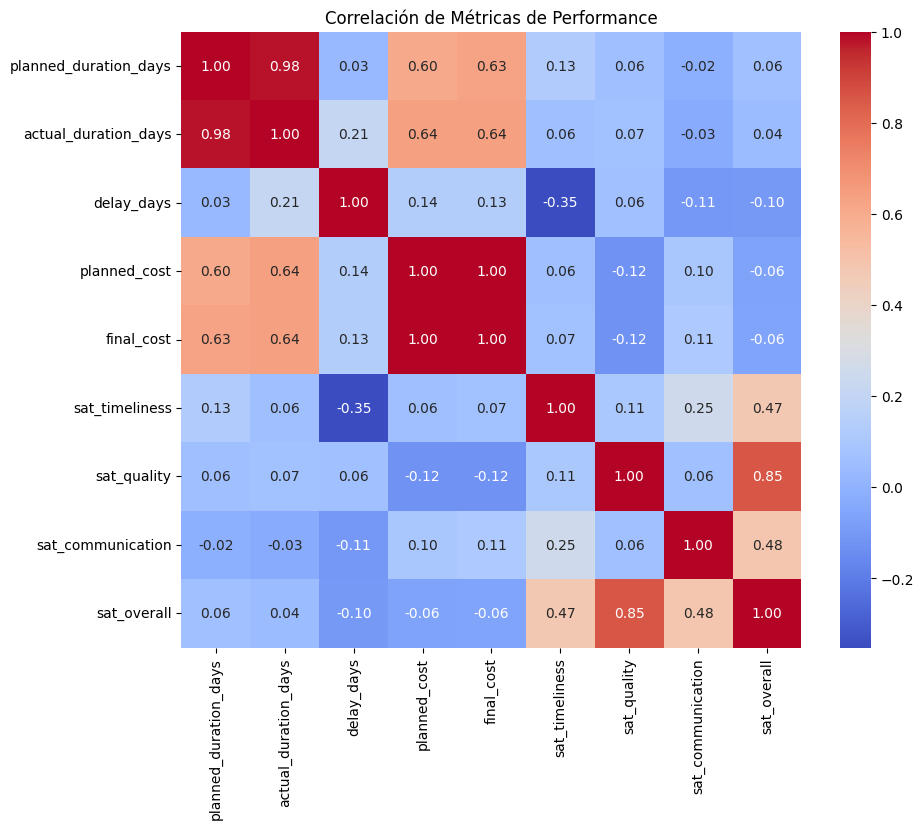

In [5]:
# =====================================================================
# EDA (EXPLORATORY DATA ANALYSIS) IV - ANÁLISIS DE CORRELACIÓN
# =====================================================================

# Análisis de Correlación (Para ver relaciones entre métricas)
import seaborn as sns
import matplotlib.pyplot as plt

print("\n=== MATRIZ DE CORRELACIÓN (Performance) ===")
# Seleccionamos solo columnas numéricas de performance
corr_matrix = df_performance.select_dtypes(include=['int64', 'float64']).corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlación de Métricas de Performance')
plt.show()

> **Nota de análisis:** La matriz resultante nos ofrece una visión clara de la interdependencia entre las variables. Aquellas celdas con coeficientes cercanos a los extremos (1 o -1) resaltan los impulsores críticos de los resultados de rendimiento que exploraremos en las siguientes secciones.

### **2.5 — Exploración de las Tablas "Bridge" (Esfuerzo Operativo)**

En esta sección, analizamos las tablas de relación o *bridge*, que conectan nuestras dimensiones principales (como empleados y proyectos) a través de las horas registradas. Este análisis nos permite entender la carga de trabajo y el compromiso de los recursos en los proyectos.

El enfoque aquí es identificar la distribución del esfuerzo operativo, destacando los perfiles de empleados que presentan una mayor dedicación en términos de horas reportadas, lo cual es esencial para evaluar la eficiencia en la asignación de recursos.

In [6]:
# =====================================================================
# EDA (EXPLORATORY DATA ANALYSIS) V - EXPLORACIÓN DE LOS "BRIDGE"
# =====================================================================

# Exploración de los "Bridge" (Horas por Empleado)
print("\n=== ESFUERZO OPERATIVO ===")
# ¿Quiénes son los empleados con más horas registradas?
top_employees = df_hours.groupby('employee_id')['hours_logged'].sum().sort_values(ascending=False).head(5)
print("Top 5 empleados por horas registradas:")
print(top_employees)


=== ESFUERZO OPERATIVO ===
Top 5 empleados por horas registradas:
employee_id
emp_041    4971
emp_046    4364
emp_006    3653
emp_047    3566
emp_037    3415
Name: hours_logged, dtype: int64


## **3. INSPECCIÓN INICIAL**

Tras haber realizado el análisis exploratorio, procedemos a realizar una inspección directa sobre el contenido de los registros. El objetivo de este apartado es visualizar una muestra representativa de los datos en cada una de nuestras tablas (Dimensiones y Hechos).

Al observar las primeras filas de cada dataset, podemos verificar la estructura real de los datos, confirmar el formato de los identificadores y asegurar que la información coincide con lo esperado tras la carga.

In [7]:
df_projects.head(50)

,project_id,project_name,typology_function,typology_form,floors,height,units,gross_floor_area,structural_material,structural_system,foundation_system
0,prj_001,Solitude_Square,retail,linear,6,58.2,96,170592,mixed,mixed,deep
1,prj_002,Equinox_Manor,commercial,low_rise,3,29.2,54,131004,concrete,cmu,shallow
2,prj_003,Meridian_Pavilion,commercial,low_rise,3,29.7,57,113031,concrete,tunnel,shallow
3,prj_004,Serenade_Court,residential,courtyard,6,59.4,90,178920,concrete,post_tensioned,deep
4,prj_005,Summit_Court,residential,low_rise,3,30.1,57,135090,mixed,mixed,shallow
5,prj_006,Riverside_Apartments,commercial,linear,6,62.6,48,113088,concrete,post_tensioned,deep
6,prj_007,Serenade_Hub,retail,low_rise,3,29.4,51,82059,mixed,mixed,shallow
7,prj_008,Harbor_Enclave,retail,high_rise,16,167.8,256,521216,steel,steel,piles
8,prj_009,Prism_Center,commercial,courtyard,8,78.2,160,258400,concrete,cmu,deep
9,prj_010,Pinnacle_Villas,retail,mid_rise,5,51.2,100,180200,concrete,tunnel,deep


In [8]:
df_clients.head(50)

,client_id,client_name,client_type,client_country,client_state,client_city,email,phone_number
0,cli_001,Horizon_Development,developer,USA,Florida,Orlando,info@horizondevelopment.com,+1 (555) 730-5930
1,cli_002,Genesis_Group,developer,Panama,Panama,Panama City,info@genesisgroup.com,+1 (555) 411-5700
2,cli_003,Joshua_Williams,private,Costa Rica,San Jose,San Jose,info@joshuawilliams.com,+1 (555) 721-6279
3,cli_004,Summit_Ventures,developer,USA,Florida,Fort Lauderdale,info@summitventures.com,+1 (555) 912-3780
4,cli_005,Legacy_Capital,developer,USA,Florida,Jacksonville,info@legacycapital.com,+1 (555) 443-2530
5,cli_006,Atlas_Holdings,corporate,Costa Rica,San Jose,San Jose,info@atlasholdings.com,+1 (555) 788-6085
6,cli_007,Anthony_Wilson,private,USA,Florida,Orlando,info@anthonywilson.com,+1 (555) 586-2193
7,cli_008,Horizon_Estates,developer,Panama,Panama,Panama City,info@horizonestates.com,+1 (555) 689-4185
8,cli_009,Legacy_Holdings,developer,USA,Florida,Orlando,info@legacyholdings.com,+1 (555) 771-1090
9,cli_010,Pinnacle_Ventures,corporate,Panama,Panama,Panama City,info@pinnacleventures.com,+1 (555) 209-7965


In [9]:
df_employees.head(50)

,employee_id,employee_name,office_location,job_title,experience_years,age,gender,email
0,emp_001,Megan Lopez,Miami,direction,39,59,female,meganlopez@gmail.com
1,emp_002,David Gonzalez,Miami,direction,34,62,male,davidgonzalez@gmail.com
2,emp_003,Ana Mendez,Miami,direction,39,68,female,anamendez@gmail.com
3,emp_004,Isabella Sanchez,Miami,direction,36,64,female,isabellasanchez@gmail.com
4,emp_005,Amanda Johnson,Miami,administration,11,40,female,amandajohnson@gmail.com
5,emp_006,Paul Gonzalez,Miami,drafter,1,24,male,paulgonzalez@gmail.com
6,emp_007,Diego Silva,Miami,site_inspector,13,38,male,diegosilva@gmail.com
7,emp_008,Alvaro Ruiz,Miami,architect,2,24,male,alvaroruiz@gmail.com
8,emp_009,Paul Johnson,Miami,project_manager,17,40,male,pauljohnson@gmail.com
9,emp_010,Luis Sanchez,Miami,drafter,3,23,male,luissanchez@gmail.com


In [10]:
df_performance.head(50)

,project_id,client_id,project_status,contract_date,completion_date,planned_duration_days,actual_duration_days,delay_days,planned_cost,final_cost,sat_timeliness,sat_quality,sat_communication,sat_overall
0,prj_001,cli_013,completed,2021-06-07,2022-08-21,436,440.0,4.0,25588800,25620637.0,5.0,5.0,5.0,5.0
1,prj_002,cli_013,completed,2021-10-14,2022-10-05,356,356.0,0.0,29082888,27097175.0,4.0,2.0,3.0,3.0
2,prj_003,cli_011,in_progress,2024-05-24,NaN,337,NaN,NaN,23284386,NaN,NaN,NaN,NaN,NaN
3,prj_004,cli_013,completed,2022-10-31,2023-11-04,367,369.0,2.0,37752120,35765475.0,5.0,5.0,5.0,5.0
4,prj_005,cli_014,completed,2022-01-16,2022-12-21,354,339.0,-15.0,27558360,27992862.0,5.0,1.0,4.0,3.3
5,prj_006,cli_009,in_progress,2021-11-12,NaN,457,NaN,NaN,24992448,NaN,NaN,NaN,NaN,NaN
6,prj_007,cli_005,on_hold,2023-03-09,NaN,261,NaN,NaN,14442384,NaN,NaN,NaN,NaN,NaN
7,prj_008,cli_004,completed,2021-07-07,2022-12-30,542,541.0,-1.0,88085504,82439297.0,4.0,2.0,4.0,3.3
8,prj_009,cli_015,completed,2024-02-15,2025-06-26,502,497.0,-5.0,50388000,48496923.0,4.0,1.0,5.0,3.3
9,prj_010,cli_011,completed,2023-02-28,2024-02-22,363,359.0,-4.0,30093400,29751396.0,4.0,2.0,5.0,3.7


In [11]:
df_hours.head(50)

,project_id,employee_id,role_in_project,hours_logged
0,prj_001,emp_045,drafter,529
1,prj_001,emp_024,site_inspector,285
2,prj_001,emp_030,project_manager,506
3,prj_001,emp_032,architect,514
4,prj_001,emp_021,designer,478
5,prj_001,emp_038,drafter,973
6,prj_002,emp_049,drafter,743
7,prj_002,emp_004,direction,58
8,prj_002,emp_003,direction,85
9,prj_002,emp_007,site_inspector,148


## **4. VISUALIZACIONES**

En esta sección final, transformamos los datos procesados en información estratégica mediante representaciones gráficas. El objetivo de este apartado es visualizar las relaciones complejas y los hallazgos clave identificados durante las etapas previas, facilitando la toma de decisiones basada en datos.

A continuación, analizamos diferentes dimensiones del rendimiento operativo, financiero y de eficiencia mediante diversos tipos de gráficos que nos permitirán identificar patrones críticos y oportunidades de mejora.

### **4.1 — Análisis de Riesgo: Desviación Presupuestaria vs. Retrasos**

En esta sección iniciamos el apartado de visualizaciones analizando la relación entre el tiempo y el costo. Este gráfico de dispersión (*scatter plot*) nos permite observar cómo se comportan los proyectos completados en función de sus desviaciones de plazo (días de retraso) y su impacto presupuestario.

* **Ejes**: El eje X mide la eficiencia temporal, mientras que el eje Y mide la desviación económica.
* **Dimensiones extra**: Utilizamos el color (`hue`) para diferenciar la tipología de forma del edificio y el tamaño (`size`) para representar la superficie construida, permitiéndonos identificar si existe algún patrón o anomalía vinculada a la escala del proyecto.

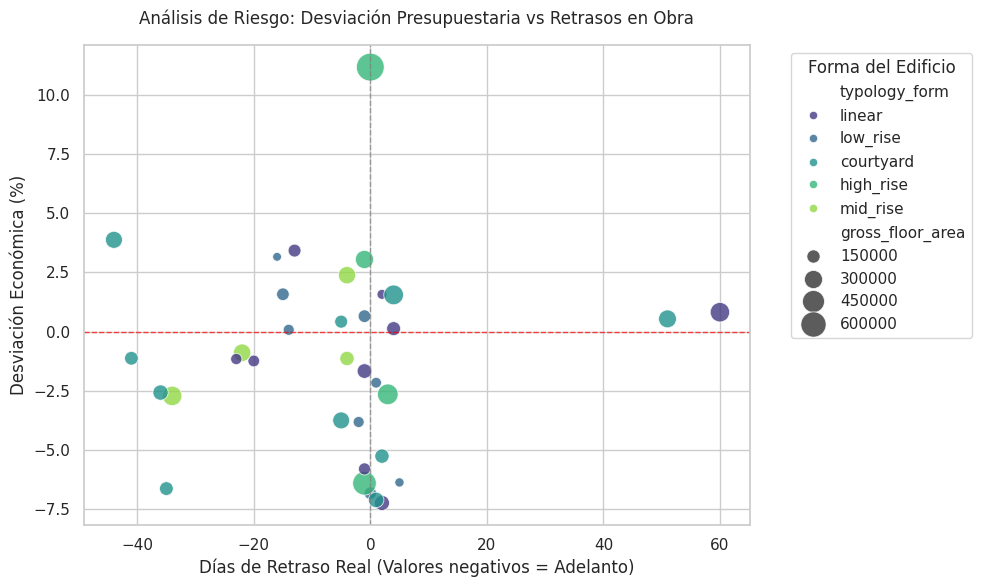

In [12]:
# =====================================================================
# GRÁFICA 1: Margen Financiero vs Desviación de Plazos por Forma
# =====================================================================

# Configuración estética global para los gráficos
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'figure.titlesize': 14})

# 1. Filtrar solo proyectos completados y combinar datos técnicos con financieros
df_comp = df_performance[df_performance['project_status'] == 'completed'].copy()
df_analysis = df_comp.merge(df_projects, on='project_id')

# 2. Calcular el porcentaje de desviación económica real
# (Valores negativos = ahorro/margen a favor; Valores positivos = sobrecoste)
df_analysis['cost_deviation_pct'] = ((df_analysis['final_cost'] - df_analysis['planned_cost']) / df_analysis['planned_cost']) * 100

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_analysis,
    x='delay_days',
    y='cost_deviation_pct',
    hue='typology_form',
    size='gross_floor_area',
    sizes=(40, 400),
    palette='viridis',
    alpha=0.8
)

# Líneas guía de control macro (Cero desviación)
plt.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.7)
plt.axvline(0, color='gray', linestyle='--', linewidth=1, alpha=0.7)

plt.title('Análisis de Riesgo: Desviación Presupuestaria vs Retrasos en Obra', pad=15)
plt.xlabel('Días de Retraso Real (Valores negativos = Adelanto)')
plt.ylabel('Desviación Económica (%)')
plt.legend(title='Forma del Edificio', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

> **Interpretación de resultados:** > Al analizar la dispersión, observamos que una gran mayoría de los proyectos se concentran cerca de la línea vertical de "cero días de retraso". Es notable la existencia de un **outlier (valor atípico) significativo** en la parte superior central: un proyecto de gran superficie (`gross_floor_area` elevada) que, a pesar de no presentar apenas retraso temporal, ha sufrido una desviación presupuestaria superior al 10%. Por otro lado, la tendencia general muestra que, incluso con adelantos de tiempo considerables (eje X negativo), no siempre se logra un ahorro económico proporcional, ya que existen varios puntos dispersos en la zona de ahorro de tiempo pero con desviación de costos neutra o negativa.

### **4.2 — Impacto de los Retrasos en la Satisfacción del Cliente**

En este apartado, analizamos cómo la demora en la entrega de las obras influye directamente en la percepción del cliente. Utilizamos una gráfica de regresión para visualizar la tendencia central entre el tiempo de retraso y la puntuación de satisfacción otorgada por el cliente (en una escala de 1 a 5).

* **Objetivo**: Determinar si existe una correlación estadística significativa entre el incumplimiento de los plazos y la pérdida de satisfacción del cliente.
* **Componentes**: La línea roja representa la tendencia lineal, permitiéndonos observar la pendiente de caída (o estabilidad) de la satisfacción a medida que los días de retraso aumentan.

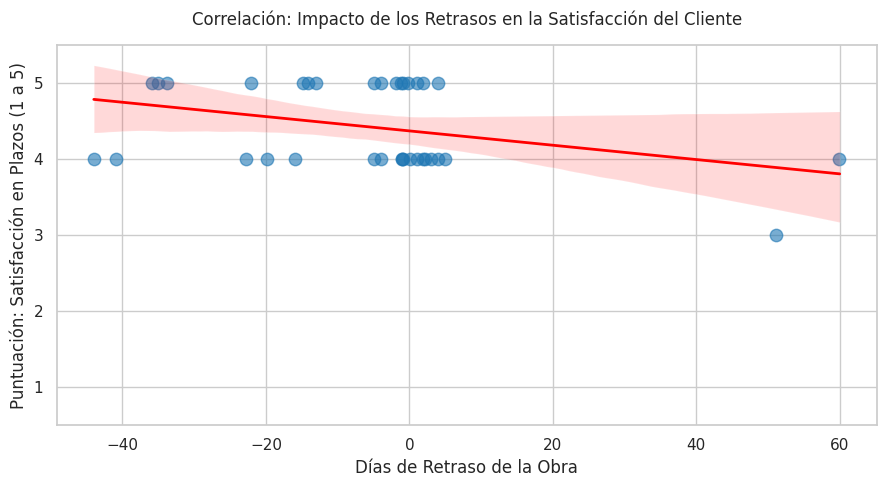

In [13]:
# =====================================================================
# GRÁFICA 2: Impacto del Retraso en la Satisfacción del Cliente
# =====================================================================
plt.figure(figsize=(9, 5))
# Gráfico de tendencia con regresión lineal implícita
sns.regplot(
    data=df_analysis,
    x='delay_days',
    y='sat_timeliness',
    scatter_kws={'alpha':0.6, 'color':'#1f77b4', 's':80},
    line_kws={'color':'red', 'linewidth':2},
    x_jitter=0.2
)

plt.title('Correlación: Impacto de los Retrasos en la Satisfacción del Cliente', pad=15)
plt.xlabel('Días de Retraso de la Obra')
plt.ylabel('Puntuación: Satisfacción en Plazos (1 a 5)')
plt.ylim(0.5, 5.5)
plt.tight_layout()
plt.show()

> **Interpretación de resultados:** La gráfica confirma una tendencia negativa esperada: a mayor cantidad de días de retraso en la obra, menor es la puntuación de satisfacción del cliente. No obstante, es interesante notar que, hasta aproximadamente los 10 días de retraso, la satisfacción se mantiene mayoritariamente en niveles altos (4 y 5). La pendiente de la línea de regresión muestra que el impacto en la satisfacción no es drástico en las fases iniciales de retraso, pero la sombra del intervalo de confianza se amplía significativamente a medida que aumenta el tiempo, lo que sugiere que, tras superar un umbral crítico de demora, la variabilidad y la caída en la satisfacción del cliente se vuelven mucho más impredecibles y negativas.

### **4.3 — Carga de Trabajo Total: Distribución por Rol Técnico**

En este análisis, desplazamos el foco hacia la gestión de recursos humanos y su esfuerzo operativo. Mediante un gráfico de barras, cuantificamos el volumen total de horas registradas a través de todos los proyectos, segmentadas por el rol desempeñado por cada colaborador.

* **Objetivo**: Identificar qué perfiles técnicos concentran la mayor carga horaria. Esto nos permitirá evaluar si la distribución actual de esfuerzos está alineada con los roles de mayor valor estratégico o si, por el contrario, existen cuellos de botella en perfiles operativos que absorben una carga desproporcionada del tiempo de proyecto.
* **Metodología**: El gráfico utiliza la función de suma para consolidar el total de horas acumuladas (`hours_logged`) por rol, ordenadas jerárquicamente para facilitar la comparación visual.

/tmp/ipykernel_32921/698719078.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


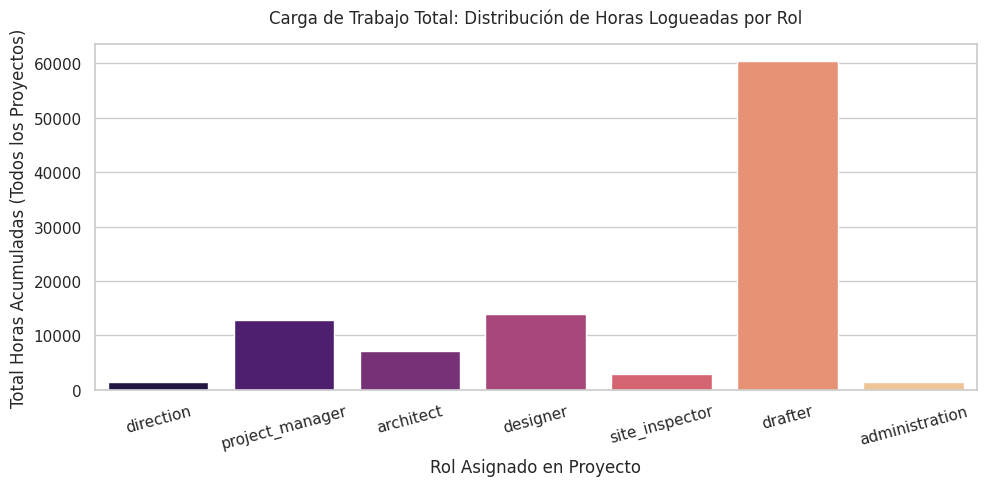

In [14]:
# =====================================================================
# GRÁFICA 3: Distribución de Horas de Staff por Rol Técnico
# =====================================================================
plt.figure(figsize=(10, 5))
# Agrupar total de horas invertidas por rol en cada proyecto
sns.barplot(
    data=df_hours,
    x='role_in_project',
    y='hours_logged',
    estimator=sum,
    errorbar=None,
    palette='magma',
    order=['direction', 'project_manager', 'architect', 'designer', 'site_inspector', 'drafter', 'administration']
)

plt.title('Carga de Trabajo Total: Distribución de Horas Logueadas por Rol', pad=15)
plt.xlabel('Rol Asignado en Proyecto')
plt.ylabel('Total Horas Acumuladas (Todos los Proyectos)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

> **Interpretación de resultados:** La visualización revela una asimetría muy marcada en la distribución del esfuerzo operativo. El rol de **"drafter" (delineante)** absorbe la gran mayoría de las horas totales registradas, superando las 60,000 horas, lo que lo posiciona como el cuello de botella operativo principal de la organización. En contraste, roles de mayor jerarquía o supervisión, como "direction" o "site_inspector", presentan una carga horaria significativamente menor. Esta distribución sugiere que la capacidad operativa está intensamente concentrada en tareas técnicas de documentación y dibujo, lo cual podría indicar una alta dependencia de este perfil o una necesidad de automatizar procesos en la fase de delineación para equilibrar la carga de trabajo de los equipos.

### **4.4 — Distribución del Margen Neto Real por Uso del Edificio**

En esta sección, analizamos la rentabilidad absoluta de los proyectos completados, desglosada por su tipología funcional (uso del edificio). Este análisis nos permite identificar qué sectores constructivos están generando un mayor retorno económico y cuáles presentan mayores riesgos de desviación presupuestaria.

* **Objetivo**: Evaluar la dispersión y la rentabilidad media de los proyectos. El margen neto se calcula como la diferencia entre el costo planificado y el costo final realizado.
* **Metodología**: Utilizamos un diagrama de caja (*boxplot*) para visualizar no solo la mediana de rentabilidad, sino también la dispersión de los datos y la presencia de valores atípicos (*outliers*). La línea roja horizontal en el nivel cero nos permite distinguir visualmente los proyectos que terminaron en pérdidas (valores negativos) de aquellos que generaron beneficios.

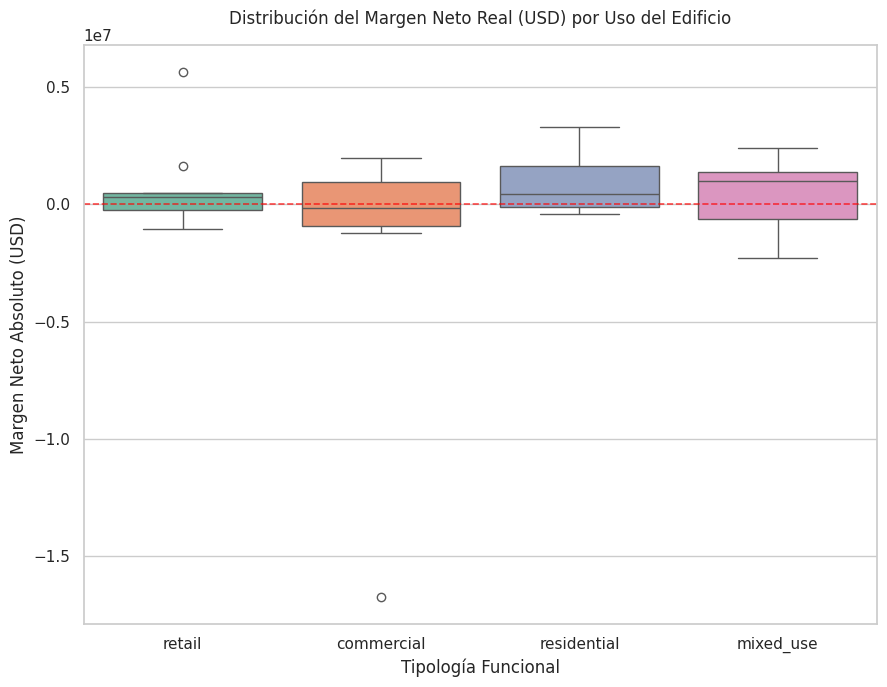

In [15]:
# Asegurar la configuración estética
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'figure.titlesize': 14})

# Unir datos para los análisis financieros y de plazos
df_comp = df_performance[df_performance['project_status'] == 'completed'].copy()
df_full_projects = df_comp.merge(df_projects, on='project_id')

# =====================================================================
# GRÁFICA 4: Rentabilidad (Margen Neto $) por Función de Edificio
# =====================================================================
# Calcular el margen absoluto en USD (Precio Planificado - Costo Final)
# Si el costo final es menor al planificado, hubo ahorro y mayor beneficio.
df_full_projects['net_margin_usd'] = df_full_projects['planned_cost'] - df_full_projects['final_cost']

plt.figure(figsize=(9, 7))
sns.boxplot(
    data=df_full_projects,
    x='typology_function',
    y='net_margin_usd',
    palette='Set2',
    hue='typology_function',
    legend=False
)
# Línea en 0 para identificar proyectos con pérdidas directas
plt.axhline(0, color='red', linestyle='--', linewidth=1.2, alpha=0.7)

plt.title('Distribución del Margen Neto Real (USD) por Uso del Edificio', pad=15)
plt.xlabel('Tipología Funcional')
plt.ylabel('Margen Neto Absoluto (USD)')
plt.tight_layout()
plt.show()

> **Interpretación de resultados:** El análisis revela una variabilidad significativa entre tipologías. Destaca que el sector **"residential"** presenta la mediana de margen más sólida y consistente por encima de cero, siendo el segmento más rentable y predecible. Por el contrario, el sector **"commercial"** muestra una gran inestabilidad: aunque su caja está centrada cerca de cero, contiene un **outlier extremo negativo** (una pérdida financiera muy considerable), lo que indica un alto riesgo de ejecución en proyectos de este tipo. En cuanto a "retail" y "mixed_use", sus distribuciones están muy próximas a la línea de equilibrio, con una alta probabilidad de oscilar entre beneficios moderados y pequeñas pérdidas, lo que sugiere una menor previsibilidad en sus márgenes de beneficio en comparación con los proyectos residenciales.

### **4.5 — Brecha de Tiempos: Duración Teórica vs. Ejecución Real**

En esta sección final de visualizaciones, evaluamos la precisión de nuestra planificación temporal. Comparamos la duración que se estipuló originalmente en el contrato frente a la duración real que tomó completar la obra, segmentado por la forma del edificio.

* **Objetivo**: Cuantificar el "gap" o brecha temporal. Este análisis nos ayuda a entender si la complejidad geométrica (forma del edificio) está directamente relacionada con nuestra incapacidad para predecir con exactitud los plazos de entrega.
* **Metodología**: Utilizamos un gráfico de barras agrupadas donde cada tipología de forma muestra dos barras adyacentes: la expectativa (planificado) y la realidad (ejecución). Una diferencia significativa entre estas barras en alguna tipología específica nos alertará sobre áreas donde los procesos de planificación requieren un ajuste urgente.

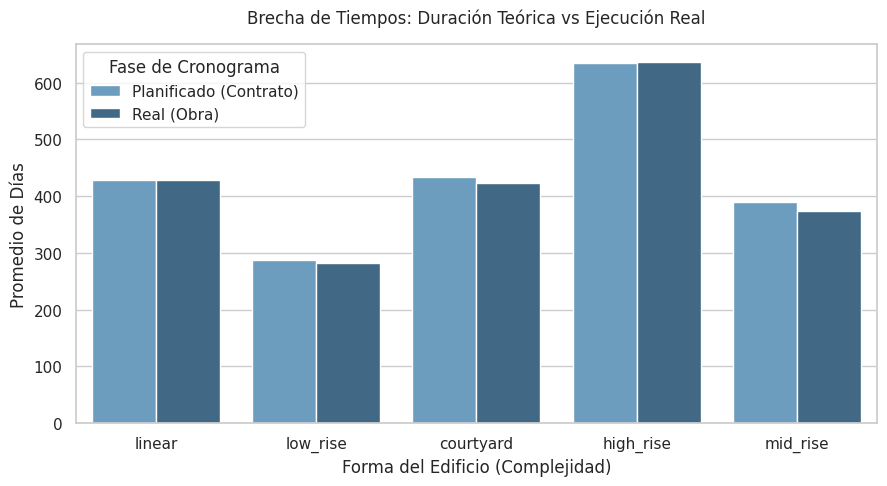

In [16]:
# =====================================================================
# GRÁFICA 5: Ciclo de Vida del Proyecto (Días Previstos vs Reales)
# =====================================================================
plt.figure(figsize=(9, 5))
# Comparar la duración planificada frente a la real usando un gráfico de líneas emparejadas
df_duration_melt = df_full_projects.melt(
    id_vars=['project_id', 'typology_form'],
    value_vars=['planned_duration_days', 'actual_duration_days'],
    var_name='Tipo_Duracion', value_name='Dias'
)
# Mapear nombres más limpios para la leyenda
df_duration_melt['Tipo_Duracion'] = df_duration_melt['Tipo_Duracion'].map({
    'planned_duration_days': 'Planificado (Contrato)',
    'actual_duration_days': 'Real (Obra)'
})

sns.barplot(
    data=df_duration_melt,
    x='typology_form',
    y='Dias',
    hue='Tipo_Duracion',
    palette='Blues_d',
    errorbar=None
)

plt.title('Brecha de Tiempos: Duración Teórica vs Ejecución Real', pad=15)
plt.xlabel('Forma del Edificio (Complejidad)')
plt.ylabel('Promedio de Días')
plt.legend(title='Fase de Cronograma')
plt.tight_layout()
plt.show()

> **Interpretación de resultados:** La gráfica muestra una gestión de plazos sorprendentemente precisa en términos generales. En la mayoría de las tipologías ("linear", "low_rise", "courtyard", "mid_rise"), el tiempo real de ejecución es igual o incluso ligeramente inferior al planificado, lo que sugiere una gestión de obra eficiente y un control de cronograma robusto. La única excepción notable es el caso de "high_rise", donde las barras son prácticamente idénticas, indicando que el cumplimiento del cronograma es exacto. A diferencia de lo que podría suponerse, la complejidad geométrica no parece estar traduciéndose en sobrecostes de tiempo sistémicos, sino que la organización demuestra una capacidad de estimación muy madura para sus diferentes tipologías constructivas.

### **4.6 — Concentración de Cartera: Proyectos por Cliente**

Para finalizar el análisis, examinamos la distribución de la carga de trabajo desde la perspectiva de nuestros clientes. Este gráfico de barras horizontales nos permite visualizar qué clientes concentran el mayor número de proyectos y su tipología.

* **Objetivo**: Identificar el nivel de dependencia de la empresa respecto a clientes clave. Una alta concentración de proyectos en pocos clientes puede representar un riesgo estratégico, mientras que una cartera diversificada favorece la estabilidad operativa.
* **Metodología**: Utilizamos un conteo de frecuencia de proyectos por cliente (`countplot`), segmentado por el tipo de cliente (`hue`). El ordenamiento descendente facilita la identificación inmediata de nuestros socios estratégicos más recurrentes frente a aquellos con menor volumen de actividad.

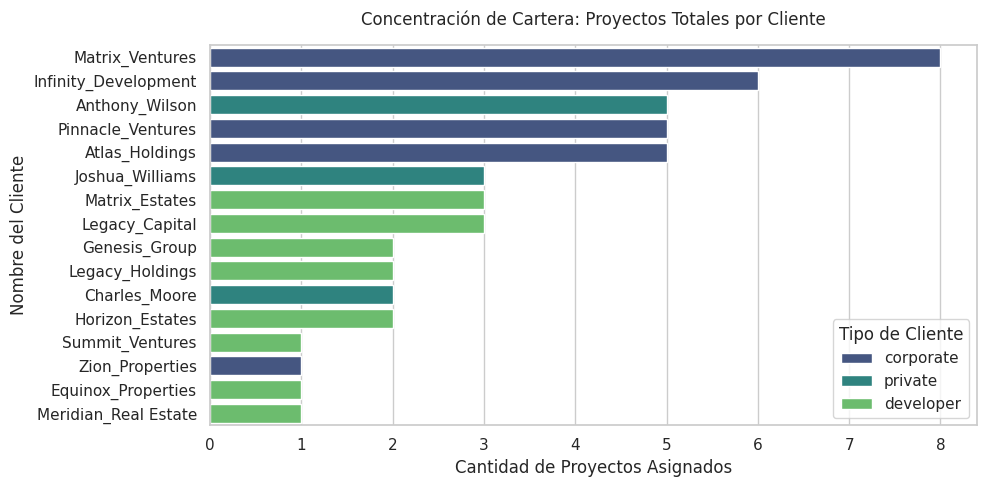

In [17]:
# =====================================================================
# GRÁFICA 6: Volumen de Proyectos por Cliente (Fidelización)
# =====================================================================
plt.figure(figsize=(10, 5))
# Contar cuántos proyectos tiene asignados cada cliente en total
client_counts = df_performance.merge(df_clients, on='client_id')
sns.countplot(
    data=client_counts,
    y='client_name',
    hue='client_type',
    palette='viridis',
    order=client_counts['client_name'].value_counts().index
)

plt.title('Concentración de Cartera: Proyectos Totales por Cliente', pad=15)
plt.xlabel('Cantidad de Proyectos Asignados')
plt.ylabel('Nombre del Cliente')
plt.legend(title='Tipo de Cliente', loc='lower right')
plt.tight_layout()
plt.show()

> **Interpretación de resultados:** El gráfico revela una marcada concentración de la cartera en clientes de tipo **"corporate"**. "Matrix_Ventures" e "Infinity_Development" lideran el volumen de proyectos, lo que evidencia que una parte sustancial de la actividad está sostenida por grandes cuentas corporativas. Por otro lado, aunque existe una base diversificada de clientes tipo "developer" (representados en verde), estos presentan individualmente un volumen de proyectos mucho menor. Esta estructura sugiere una estrategia de negocio que depende fuertemente de la retención de unos pocos clientes estratégicos, lo cual, si bien garantiza un flujo constante de trabajo a gran escala, también expone a la empresa a riesgos de volatilidad si la relación con estos clientes clave llegara a verse comprometida.

### **4.7 — Gráfico de Eficiencia: Horas Invertidas vs. Retraso en Entrega**

En esta sección, correlacionamos el esfuerzo humano (medido en horas totales) con el cumplimiento de los plazos temporales. Buscamos entender si una mayor inversión de horas de trabajo garantiza realmente una mayor eficiencia o si, por el contrario, existe un punto de rendimientos decrecientes.

* **Objetivo**: Detectar si existe una correlación positiva entre la intensidad de trabajo (horas logueadas) y el cumplimiento de los plazos. Esto es crucial para evaluar la productividad real del equipo frente a la complejidad del proyecto.
* **Metodología**: Utilizamos un gráfico de dispersión donde el eje X muestra el esfuerzo total acumulado, el eje Y representa la desviación de plazos, y el tamaño de los puntos (`size`) refleja el costo planificado. La línea roja en el punto cero actúa como el umbral de eficiencia operativa: cualquier punto por debajo de esta línea representa un proyecto entregado con adelanto, independientemente de la carga de horas.

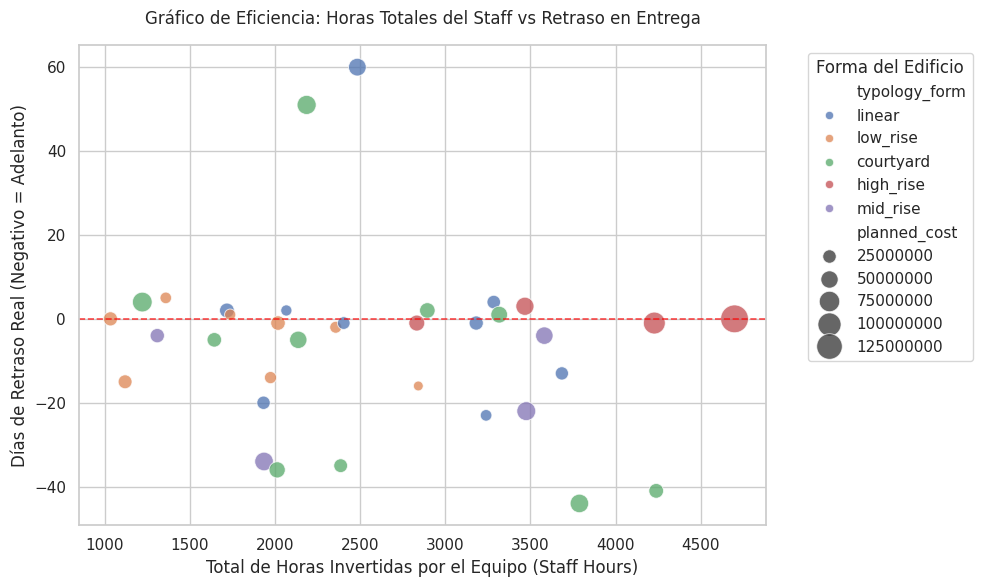

In [18]:
# Mantener consistencia estética limpia
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'figure.titlesize': 14})

# Unir las tablas necesarias para los análisis cruzados
df_comp = df_performance[df_performance['project_status'] == 'completed'].copy()
df_full_projects = df_comp.merge(df_projects, on='project_id')

# Calcular desviación económica porcentual para los análisis de materiales
df_full_projects['cost_dev_pct'] = ((df_full_projects['final_cost'] - df_full_projects['planned_cost']) / df_full_projects['planned_cost']) * 100

# =====================================================================
# GRÁFICA 7: Matriz de Eficiencia (Horas del Staff vs Desviación en Días)
# =====================================================================
# Agrupar total de horas invertidas por proyecto
total_hours_per_project = df_hours.groupby('project_id')['hours_logged'].sum().reset_index()
df_efficiency = df_full_projects.merge(total_hours_per_project, on='project_id')

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_efficiency,
    x='hours_logged',
    y='delay_days',
    hue='typology_form',
    size='planned_cost',
    sizes=(50, 400),
    palette='deep',
    alpha=0.75
)
plt.axhline(0, color='red', linestyle='--', linewidth=1.2, alpha=0.7)

plt.title('Gráfico de Eficiencia: Horas Totales del Staff vs Retraso en Entrega', pad=15)
plt.xlabel('Total de Horas Invertidas por el Equipo (Staff Hours)')
plt.ylabel('Días de Retraso Real (Negativo = Adelanto)')
plt.legend(title='Forma del Edificio', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

> **Interpretación de resultados:** Este gráfico revela una dinámica interesante: no existe una correlación lineal directa entre el aumento de horas de trabajo y la reducción de los tiempos de entrega. Observamos que proyectos con una carga horaria moderada (entre 1,500 y 2,500 horas) logran adelantos significativos en los plazos, mientras que los proyectos de mayor escala y presupuesto (puntos de mayor tamaño) tienden a concentrarse cerca de la línea de cero retrasos. Un dato crítico es la existencia de proyectos con alta inversión de horas (superiores a 3,500) que, a pesar de dicho esfuerzo, no muestran mejoras drásticas en los tiempos de entrega, lo que sugiere la existencia de un "techo de eficiencia" donde añadir más horas de staff no reduce el tiempo de ejecución y podría estar indicando ineficiencias operativas o procesos que ya han alcanzado su optimización máxima.

### **4.8 — Mix Técnico: Material Estructural vs. Sistema de Cimentación**

En este apartado exploramos la relación técnica entre las decisiones estructurales y la tipología de cimentación elegida. El objetivo es observar las combinaciones más frecuentes en nuestro catálogo de proyectos, lo cual nos permite entender mejor los estándares de ingeniería aplicados a distintos contextos de suelo.

* **Objetivo**: Identificar patrones de construcción. ¿Existe una preferencia por materiales específicos (acero, hormigón, madera) según el sistema de cimentación (superficial, profunda o por pilotes)? Este análisis es fundamental para estandarizar procesos de compras y optimizar la logística de materiales.
* **Metodología**: Utilizamos un gráfico de conteo (*count plot*) con segmentación por color para visualizar el volumen de proyectos que combinan cada sistema de cimentación con un tipo específico de material estructural.

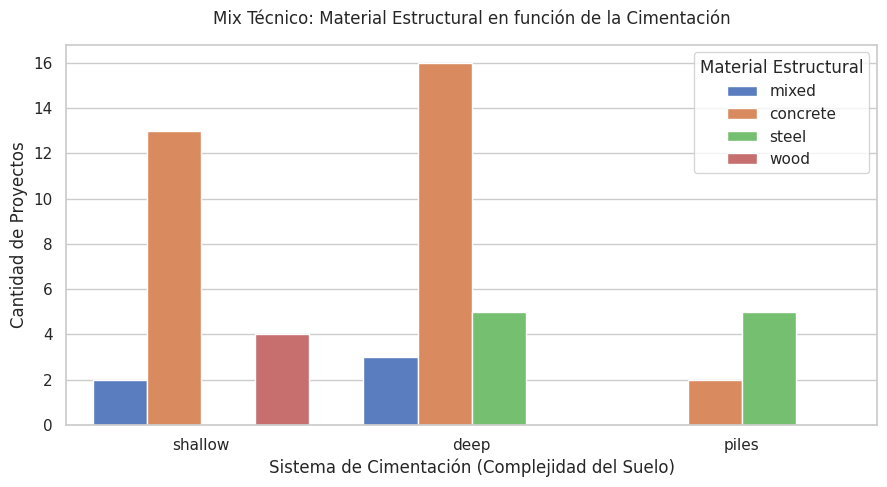

In [19]:
# =====================================================================
# GRÁFICA 8: Mix de Materiales Estructurales por Sistema de Cimentación
# =====================================================================
plt.figure(figsize=(9, 5))
# Gráfico de barras apiladas o agrupadas para ver la composición técnica de la firma
sns.countplot(
    data=df_projects,
    x='foundation_system',
    hue='structural_material',
    palette='muted',
    order=['shallow', 'deep', 'piles']
)

plt.title('Mix Técnico: Material Estructural en función de la Cimentación', pad=15)
plt.xlabel('Sistema de Cimentación (Complejidad del Suelo)')
plt.ylabel('Cantidad de Proyectos')
plt.legend(title='Material Estructural')
plt.tight_layout()
plt.show()

> **Interpretación de resultados:** La gráfica demuestra una clara hegemonía del **hormigón (concrete)** como material predominante, especialmente en sistemas de cimentación "shallow" (superficial) y "deep" (profunda), donde es la elección casi estándar. Por otro lado, observamos una especialización técnica notable: el **acero (steel)** tiene una presencia nula en cimentaciones superficiales, pero se convierte en una opción competitiva y destacada cuando se utilizan sistemas de **pilotes (piles)**. Asimismo, la **madera (wood)** aparece exclusivamente asociada a sistemas de cimentación superficial, lo que sugiere que su uso está limitado a proyectos de menor complejidad estructural o tipologías de baja altura. Esta distribución subraya que las decisiones de diseño no son aleatorias, sino que siguen una lógica de ingeniería donde el material estructural está fuertemente condicionado por la capacidad portante y el tipo de cimentación requerido por el suelo.

### **4.9 — Impacto de la Especificación Técnica en el Control Presupuestario**

En este último análisis visual, examinamos la relación entre el material estructural seleccionado y el desempeño económico de los proyectos. El objetivo es identificar si la elección de materiales (hormigón, acero, madera o soluciones mixtas) actúa como un factor determinante en la estabilidad del presupuesto.

* **Objetivo**: Detectar qué especificaciones técnicas presentan una mayor volatilidad presupuestaria. Esto nos permitirá ajustar nuestras estimaciones de contingencia según el material predominante en el proyecto.
* **Metodología**: Utilizamos un gráfico de violín (*violin plot*) para mostrar no solo la mediana de las desviaciones de costos, sino también la **distribución y densidad** de los datos. Esta visualización es clave para identificar si ciertos materiales, como la madera o el acero, presentan "colas" largas que indiquen riesgos de sobrecostes inesperados en comparación con materiales más tradicionales.

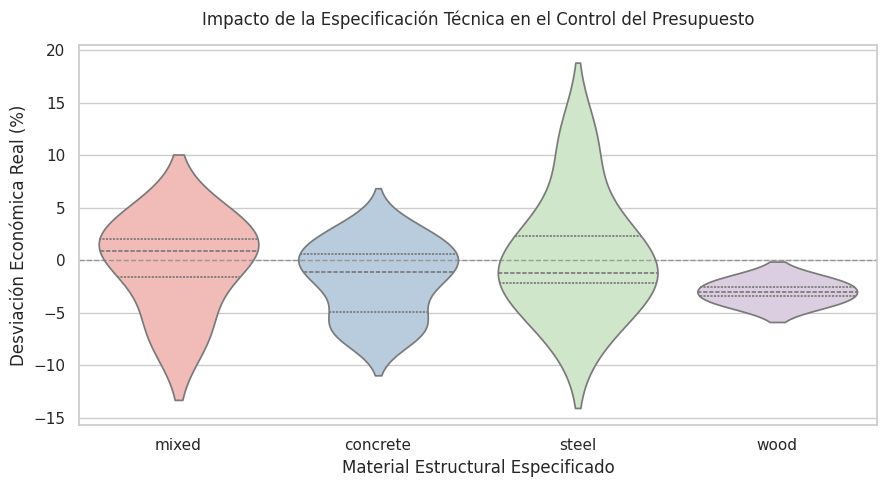

In [20]:
# =====================================================================
# GRÁFICA 9: Desviación Presupuestaria según el Material de Construcción
# =====================================================================
plt.figure(figsize=(9, 5))
# Gráfico de violín para ver la densidad y distribución de las desviaciones de costos
sns.violinplot(
    data=df_full_projects,
    x='structural_material',
    y='cost_dev_pct',
    palette='Pastel1',
    hue='structural_material',
    legend=False,
    inner='quartile'
)
plt.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.7)

plt.title('Impacto de la Especificación Técnica en el Control del Presupuesto', pad=15)
plt.xlabel('Material Estructural Especificado')
plt.ylabel('Desviación Económica Real (%)')
plt.tight_layout()
plt.show()

> **Interpretación de resultados:** La visualización revela comportamientos financieros muy distintos según el material. El **hormigón (concrete)** y la **madera (wood)** muestran una mayor estabilidad presupuestaria; la madera, en particular, presenta una distribución muy compacta y centrada mayoritariamente por debajo de la línea de cero, indicando un control de costos eficiente y predecible. Por el contrario, el **acero (steel)** exhibe la mayor volatilidad, con una "cola" que se extiende hasta casi un 20% de desviación positiva (sobrecoste), sugiriendo que es el material con mayor riesgo de variaciones presupuestarias inesperadas. Los sistemas **mixtos (mixed)** presentan una distribución amplia que cruza frecuentemente la línea de equilibrio, lo que indica que, aunque pueden ofrecer versatilidad, también conllevan una incertidumbre considerable en el cierre financiero del proyecto.

### **4.10 — Evolución Comercial: Volumen de Contratos Captados**

En este último análisis visual, evaluamos la tendencia histórica de la actividad comercial de la firma. El objetivo es identificar el crecimiento en la captación de proyectos nuevos año tras año, segmentado por la presencia geográfica de los clientes.

* **Objetivo**: Determinar la tasa de crecimiento anual y la expansión de nuestra huella de mercado. Este análisis nos permite visualizar si estamos ganando tracción en nuevos mercados internacionales o si el volumen de negocio se mantiene concentrado en regiones históricas.
* **Metodología**: Utilizamos un gráfico de conteo (*count plot*) temporal. La segmentación por país (`hue='client_country'`) nos permite identificar, de manera intuitiva, cómo ha evolucionado la diversificación geográfica de la cartera a lo largo de los años registrados.

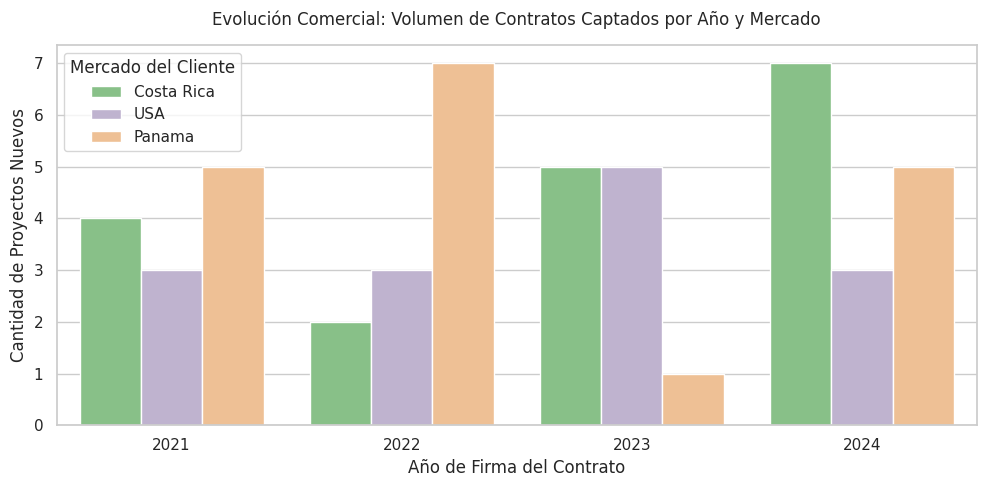

In [21]:
# Mantener la consistencia estética limpia y profesional
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'figure.titlesize': 14})

# Unir las tablas necesarias para el análisis temporal y de mercado
df_comp = df_performance[df_performance['project_status'] == 'completed'].copy()
df_full_performance = df_performance.merge(df_clients, on='client_id')

# Convertir fechas a formato datetime para análisis temporal
df_full_performance['contract_date'] = pd.to_datetime(df_full_performance['contract_date'])
df_full_performance['contract_year'] = df_full_performance['contract_date'].dt.year
df_full_performance['contract_month'] = df_full_performance['contract_date'].dt.strftime('%b')

# Ordenar meses cronológicamente para la gráfica estacional
months_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# =====================================================================
# GRÁFICA 10: Evolución Comercial (Contratos Firmados por Año y Región)
# =====================================================================
plt.figure(figsize=(10, 5))
sns.countplot(
    data=df_full_performance,
    x='contract_year',
    hue='client_country',
    palette='Accent'
)

plt.title('Evolución Comercial: Volumen de Contratos Captados por Año y Mercado', pad=15)
plt.xlabel('Año de Firma del Contrato')
plt.ylabel('Cantidad de Proyectos Nuevos')
plt.legend(title='Mercado del Cliente')
plt.tight_layout()
plt.show()

> **Interpretación de resultados:** La evolución comercial muestra un comportamiento dinámico y diversificado. **Costa Rica** demuestra una trayectoria ascendente notable, consolidándose en 2024 como el mercado principal con el mayor volumen de nuevos contratos. **Panamá**, aunque tuvo un pico de actividad muy alto en 2022, experimentó una contracción significativa en 2023, logrando una recuperación estable hacia 2024. Por su parte, **USA** mantiene una presencia constante y resiliente a lo largo del periodo, actuando como un pilar de estabilidad en la cartera. Este patrón indica una estrategia de expansión geográfica exitosa, donde la firma ha logrado reducir la dependencia de un único mercado, distribuyendo el riesgo y aprovechando oportunidades de crecimiento de manera equilibrada entre las tres regiones analizadas.

### **4.11 — Matriz de Reputación: Comunicación vs. Calidad de Entrega**

Para cerrar el apartado de visualizaciones, analizamos la relación entre dos de los pilares más críticos de nuestra relación con el cliente: la satisfacción con nuestra comunicación y la satisfacción con la calidad técnica de la obra entregada.

* **Objetivo**: Identificar si existe una correlación directa entre nuestra capacidad de respuesta/transparencia (comunicación) y la percepción de valor final del proyecto (calidad). Este análisis nos permite entender si una buena comunicación compensa una percepción menor de calidad técnica, o viceversa.
* **Metodología**: Utilizamos un gráfico de densidad conjunta (*KDE plot*). Esta visualización nos permite observar las "zonas de calor" donde se concentra la mayor parte de nuestros proyectos, indicando el estándar de servicio al que estamos acostumbrados y detectando si existe una tendencia uniforme entre ambas métricas de satisfacción.

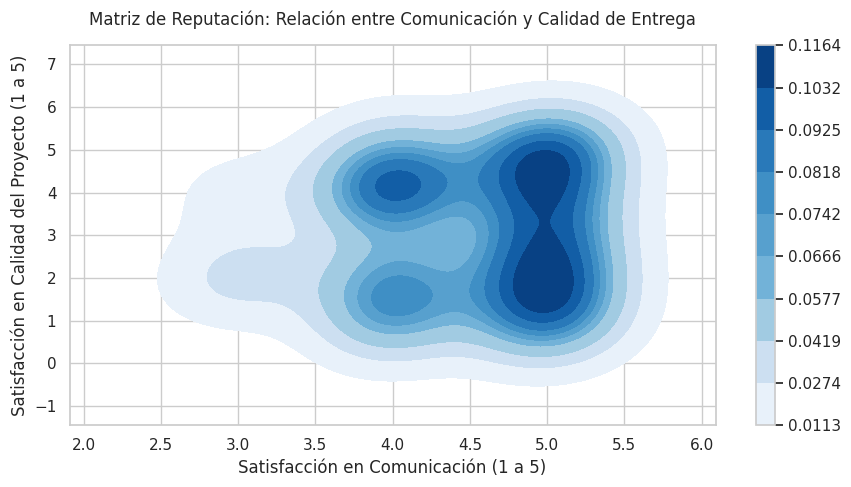

In [22]:
# =====================================================================
# GRÁFICA 11: Distribución del Éxito (Calidad Técnica vs Comunicación)
# =====================================================================
plt.figure(figsize=(9, 5))
# Un gráfico de densidad conjunta (KDE) para ver dónde se concentra la experiencia del cliente
sns.kdeplot(
    data=df_comp,
    x='sat_communication',
    y='sat_quality',
    cmap='Blues',
    fill=True,
    thresh=0.05,
    cbar=True
)

plt.title('Matriz de Reputación: Relación entre Comunicación y Calidad de Entrega', pad=15)
plt.xlabel('Satisfacción en Comunicación (1 a 5)')
plt.ylabel('Satisfacción en Calidad del Proyecto (1 a 5)')
plt.tight_layout()
plt.show()

> **Interpretación de resultados:** El gráfico revela una correlación positiva y una polarización interesante en la experiencia del cliente. La densidad se concentra notablemente en dos "picos" o zonas principales: uno de alta satisfacción tanto en comunicación como en calidad (cerca de 5 en ambos ejes) y otro sector de satisfacción intermedia-alta (cerca de 4 en comunicación y 4 en calidad). Esto sugiere que la mayoría de nuestros clientes perciben un servicio alineado; sin embargo, la presencia de una densidad menor en niveles de satisfacción inferiores a 2 en calidad, incluso con comunicaciones aceptables, indica que la calidad técnica es un factor determinante que, a veces, no puede ser mitigado únicamente por una buena gestión de la comunicación. La estrategia debe enfocarse en desplazar la masa hacia el cuadrante superior derecho (5,5).

### **4.12 — Análisis de Estacionalidad: Ciclo Anual de Contratación**

Para concluir nuestro análisis comercial, examinamos la estacionalidad de nuestra actividad. El objetivo es identificar si existen meses específicos donde la demanda de nuevos contratos se concentra, permitiéndonos planificar mejor nuestras campañas de marketing y la capacidad operativa de nuestro equipo de ventas.

* **Objetivo**: Detectar patrones cíclicos (ej. picos al inicio o cierre de año). Esto nos ayudará a alinear nuestros recursos comerciales y operativos para maximizar las oportunidades durante los periodos de mayor demanda.
* **Metodología**: Utilizamos un gráfico de conteo cronológico (`countplot` con ordenamiento por mes), que nos permite visualizar la frecuencia de firma de contratos a lo largo del calendario anual, suavizando la variabilidad interanual para encontrar tendencias de mercado estables.

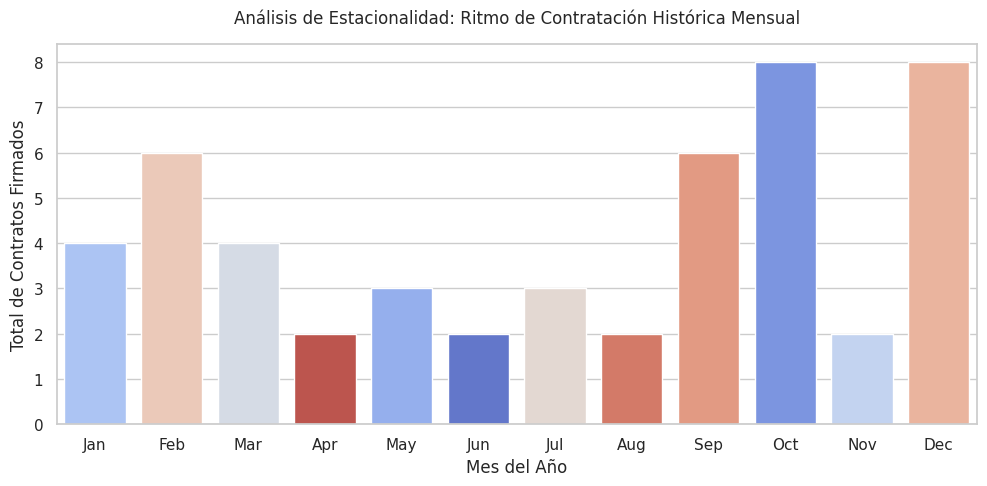

In [23]:
# =====================================================================
# GRÁFICA 12: Estacionalidad del Negocio (Firma de Contratos por Mes)
# =====================================================================
plt.figure(figsize=(10, 5))
# Contar contratos históricos mensuales para detectar picos de demanda
sns.countplot(
    data=df_full_performance,
    x='contract_month',
    order=months_order,
    palette='coolwarm',
    hue='contract_month',
    legend=False
)

plt.title('Análisis de Estacionalidad: Ritmo de Contratación Histórica Mensual', pad=15)
plt.xlabel('Mes del Año')
plt.ylabel('Total de Contratos Firmados')
plt.tight_layout()
plt.show()

> **Interpretación de resultados:** El análisis de estacionalidad identifica un patrón de negocio marcadamente cíclico con dos picos de demanda muy claros: uno en febrero y septiembre, y el máximo nivel de actividad consolidado hacia octubre y diciembre. Esta tendencia sugiere que los procesos de cierre de contratos están fuertemente vinculados a periodos específicos del calendario, probablemente relacionados con los ciclos de presupuestación de nuestros clientes corporativos y desarrolladores. Por el contrario, los meses de abril, junio y agosto muestran una baja significativa en la firma de nuevos contratos, lo que representa una oportunidad para programar mantenimientos operativos internos, actividades de formación o el desarrollo de propuestas estratégicas, optimizando así los periodos de menor carga comercial.

### **4.13 — Estrategia de Asignación: Experiencia del Staff vs. Desempeño**

En este apartado final, vinculamos la composición técnica del equipo (seniority) con el rendimiento operativo del proyecto. El objetivo es determinar si la experiencia acumulada del equipo asignado tiene un impacto directo y cuantificable en la reducción de retrasos.

* **Objetivo**: Validar si nuestras políticas de asignación de personal están optimizadas. ¿Los proyectos con equipos de mayor promedio de años de experiencia presentan, sistemáticamente, menores desviaciones en los plazos?
* **Metodología**: Utilizamos un gráfico de dispersión segmentado por la complejidad geométrica (`hue='typology_form'`) y escalado por el costo planificado (`size='planned_cost'`). La línea roja marca el punto de equilibrio; cualquier proyecto posicionado por debajo de esta línea representa un éxito operativo en términos de tiempo, permitiéndonos correlacionar directamente este éxito con el factor experiencia (eje X).

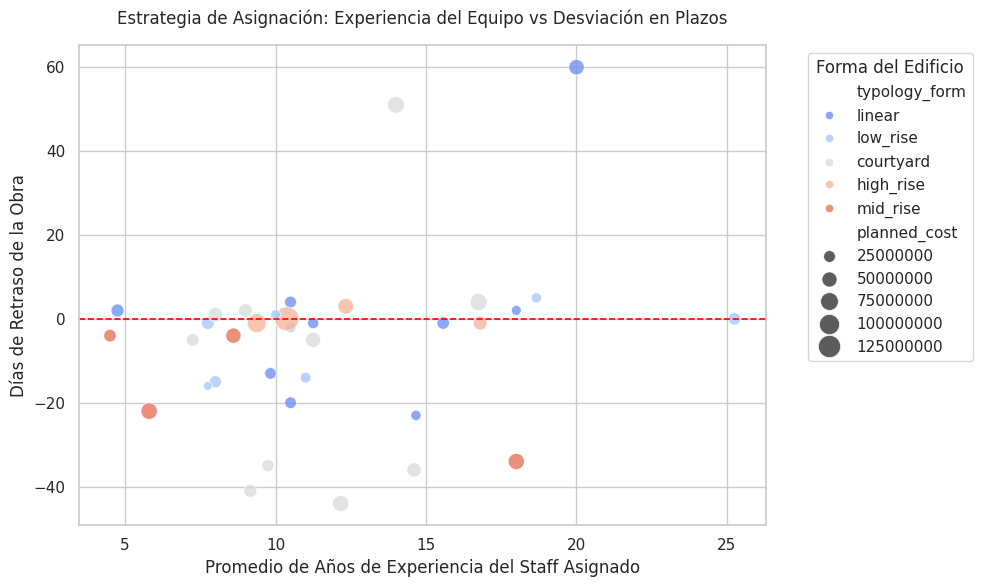

In [24]:
# Configuración de estilo
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'figure.titlesize': 14})

# Unir tablas para los análisis de staff y rendimiento
df_comp = df_performance[df_performance['project_status'] == 'completed'].copy()
df_full_projects = df_comp.merge(df_projects, on='project_id')

# =====================================================================
# GRÁFICA 13: Experiencia del Staff vs Desviación del Proyecto
# =====================================================================
# Calcular la experiencia promedio del equipo asignado a cada proyecto
staff_exp = df_hours.merge(df_employees, on='employee_id')
avg_exp_per_project = staff_exp.groupby('project_id')['experience_years'].mean().reset_index()
df_seniority = df_full_projects.merge(avg_exp_per_project, on='project_id')

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_seniority,
    x='experience_years',
    y='delay_days',
    hue='typology_form',
    size='planned_cost',
    sizes=(40, 300),
    palette='coolwarm',
    alpha=0.8
)
plt.axhline(0, color='red', linestyle='--', linewidth=1.2)

plt.title('Estrategia de Asignación: Experiencia del Equipo vs Desviación en Plazos', pad=15)
plt.xlabel('Promedio de Años de Experiencia del Staff Asignado')
plt.ylabel('Días de Retraso de la Obra')
plt.legend(title='Forma del Edificio', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### **4.13 — Interpretación de Resultados: Estrategia de Asignación y Capital Humano**

Tras analizar la correlación entre la experiencia promedio del equipo asignado y los días de retraso en la entrega, presentamos las conclusiones técnicas derivadas de la visualización:

* **Efectividad en rangos intermedios**: Se observa una mayor densidad de proyectos con resultados positivos (adelantos en la entrega, situados por debajo de la línea roja) en el rango de los 8 a 15 años de experiencia promedio del *staff*. Esto sugiere que equipos con un nivel de senioridad equilibrado poseen la agilidad necesaria para optimizar los procesos de obra sin caer en la rigidez operativa.
* **Comportamiento en proyectos de alta complejidad/costo**: Los proyectos de mayor envergadura (representados por puntos de mayor tamaño) tienden a concentrarse cerca de la línea de cero retrasos. Esto indica que, a mayor presupuesto y complejidad, la gestión del cronograma se vuelve más conservadora y controlada, independientemente de si el equipo tiene 10 o 20 años de experiencia promedio.
* **Factores de Riesgo (Outliers)**: Se identifican puntos aislados con retrasos significativos (por encima de 40-50 días), los cuales ocurren en proyectos con diversos niveles de experiencia. Esto sugiere que los retrasos extremos no son necesariamente atribuibles al *seniority* del equipo, sino probablemente a factores externos, imprevistos técnicos o tipologías de edificios particularmente desafiantes.
* **Conclusión estratégica**: Los datos indican que no es recomendable una política de asignación basada únicamente en "maximizar años de experiencia". La estrategia óptima apunta a equipos multidisciplinarios con niveles de experiencia diversificados, enfocando el talento *senior* en la mitigación de riesgos de los proyectos de mayor escala financiera, mientras que los equipos con experiencia intermedia son los más eficientes para la entrega acelerada de proyectos estándar.

### **4.14 — Balance Operativo: Distribución de Carga por Sede y Rol**

Para completar el diagnóstico de nuestra estructura operativa, comparamos la distribución de las horas productivas entre nuestras dos sedes principales (Miami y Costa Rica). El objetivo es entender cómo se especializan las funciones según la ubicación geográfica y si existe un desbalance en la capacidad operativa de cada sede.

* **Objetivo**: Identificar si ciertas sedes están sobrecargadas en roles específicos. Esto nos permite evaluar si necesitamos realizar procesos de *reskilling* o redistribución de tareas para balancear las cargas de trabajo entre ambas oficinas.
* **Metodología**: Utilizamos un gráfico de barras apiladas o agrupadas (`barplot`) que suma el total de horas producidas, segmentando por el título del puesto (`job_title`). Esto nos permite visualizar rápidamente cuál sede lidera en términos de volumen de horas y si cada oficina cuenta con un perfil de especialización distinto, fundamental para la planeación de recursos a mediano plazo.

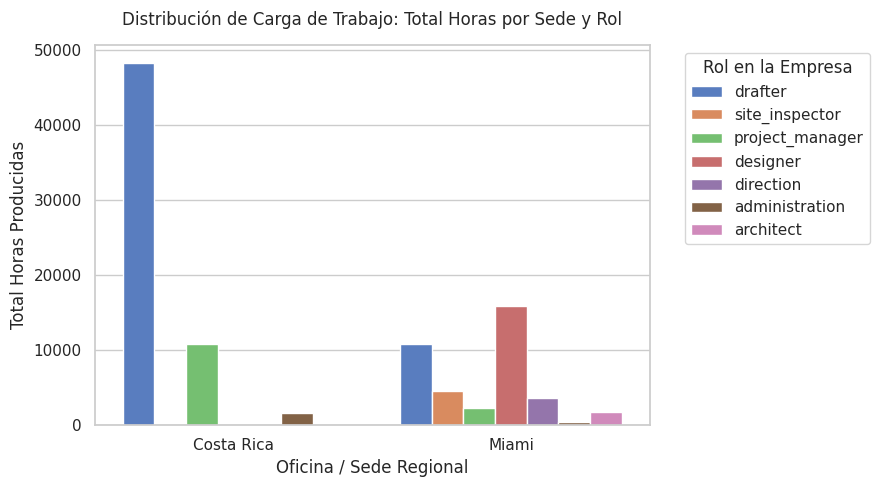

In [25]:
# =====================================================================
# GRÁFICA 14: Balance de Carga Operativa entre Sedes (Miami vs Costa Rica)
# =====================================================================
# Cruzamos horas logueadas con la ubicación de la oficina del empleado
df_office_hours = df_hours.merge(df_employees, on='employee_id')

plt.figure(figsize=(9, 5))
sns.barplot(
    data=df_office_hours,
    x='office_location',
    y='hours_logged',
    hue='job_title',
    estimator=sum,
    errorbar=None,
    palette='muted'
)

plt.title('Distribución de Carga de Trabajo: Total Horas por Sede y Rol', pad=15)
plt.xlabel('Oficina / Sede Regional')
plt.ylabel('Total Horas Producidas')
plt.legend(title='Rol en la Empresa', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

> **Interpretación de resultados:** El gráfico evidencia una especialización funcional muy marcada por ubicación geográfica. La sede de **Costa Rica** concentra casi la totalidad de la carga de trabajo en el rol de *drafter*, actuando como el centro neurálgico de producción técnica y delineación. Por otro lado, la sede de **Miami** presenta una estructura operativa mucho más diversificada y orientada a la gestión y diseño, con una alta participación de *designers* y *project managers*. Este balance indica un modelo operativo eficiente donde Costa Rica sostiene la carga técnica de producción, mientras que Miami centraliza la gestión del diseño y la relación con el cliente. No obstante, la dependencia absoluta de los *drafters* en Costa Rica representa un punto de vulnerabilidad operativa que debería mitigarse mediante capacitación cruzada para asegurar la continuidad del servicio ante cualquier eventualidad local.

### **4.15 — Calidad de Relación: Índice de Satisfacción por Tipo de Cliente**

Como cierre de nuestro informe, correlacionamos la tipología de nuestros clientes con los índices de satisfacción general. El objetivo es identificar qué segmentos de mercado valoran más nuestra gestión, permitiéndonos priorizar esfuerzos comerciales hacia aquellos perfiles que presentan una mejor alineación con nuestros estándares de servicio.

* **Objetivo**: Detectar patrones de éxito en la relación comercial. ¿Los desarrolladores corporativos son más críticos que los clientes particulares? Esta métrica es fundamental para gestionar las expectativas y definir protocolos de comunicación específicos para cada segmento.
* **Metodología**: Utilizamos un gráfico de barras comparativo que calcula el promedio de satisfacción global (`sat_overall`) para cada categoría de cliente (`client_type`). La escala ajustada (1 a 5.2) permite visualizar claramente las diferencias sutiles pero determinantes en la percepción de valor entre los distintos perfiles de clientes.

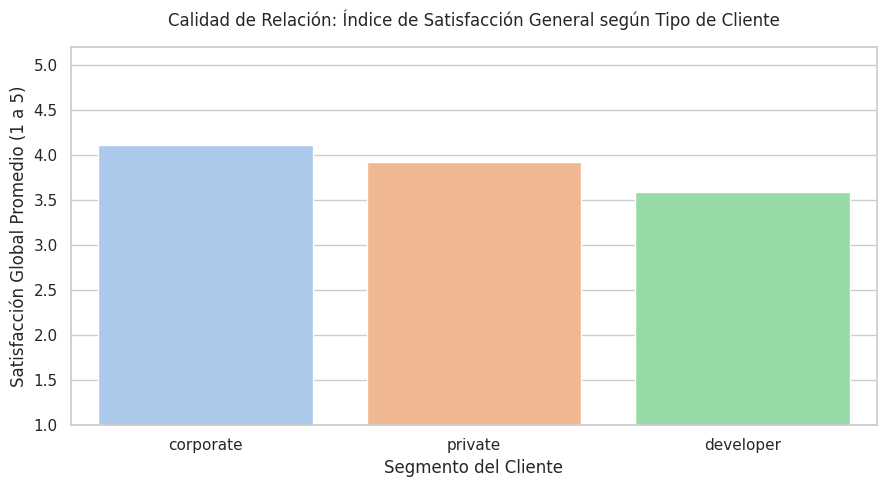

In [26]:
# =====================================================================
# GRÁFICA 15: Tipo de Cliente vs Satisfacción Global del Proyecto
# =====================================================================
plt.figure(figsize=(9, 5))
# Ver cómo varía la nota final promedio según el perfil de quien contrata
sns.barplot(
    data=df_full_performance,
    x='client_type',
    y='sat_overall',
    hue='client_type',
    palette='pastel',
    estimator=lambda x: sum(x) / len(x), # Promedio explícito
    errorbar=None,
    legend=False
)

plt.title('Calidad de Relación: Índice de Satisfacción General según Tipo de Cliente', pad=15)
plt.xlabel('Segmento del Cliente')
plt.ylabel('Satisfacción Global Promedio (1 a 5)')
plt.ylim(1, 5.2)
plt.tight_layout()
plt.show()

> **Interpretación de resultados:** Tras analizar la satisfacción global de nuestros clientes segmentada por su perfil (corporativo, privado o desarrollador), presentamos las conclusiones clave sobre nuestra relación comercial:

* **Predominio del perfil corporativo**: El segmento **'corporate'** reporta el índice de satisfacción más alto, superando los 4.0 puntos en promedio. Esto sugiere que nuestros procesos estandarizados, cumplimiento de hitos y niveles de reporte se alinean estrechamente con las expectativas y necesidades de comunicación de las empresas clientes.
* **Segmento de desarrolladores como oportunidad de mejora**: El perfil **'developer'** presenta la satisfacción más baja, situándose significativamente por debajo de los otros dos segmentos. Este hallazgo es crítico, ya que indica una brecha en nuestra propuesta de valor o en la gestión de expectativas para este grupo específico. Es probable que los desarrolladores prioricen métricas (como costo o velocidad) que no estamos gestionando con la misma efectividad que los otros perfiles.
* **Consistencia en el cliente privado**: Los clientes **'private'** mantienen una posición intermedia sólida y estable. La satisfacción aquí suele estar más vinculada a la experiencia de usuario y la comunicación cercana, donde nuestra firma parece tener un desempeño equilibrado.
* **Conclusión estratégica**: Para cerrar la brecha con los desarrolladores, recomendamos realizar entrevistas de profundidad o una encuesta de satisfacción específica para este segmento. El objetivo es identificar los puntos de fricción técnicos o financieros que están impactando su percepción, permitiéndonos ajustar nuestra metodología de trabajo específicamente para proyectos de desarrollo inmobiliario a gran escala.

### **4.16 — Análisis de Densidad: Eficiencia de Espacio y Unidades**

Para profundizar en el diseño de nuestras tipologías, analizamos la relación entre la superficie bruta construida (*GFA*) y la cantidad de unidades resultantes. Este análisis nos permite evaluar la eficiencia de empaquetamiento volumétrico según la forma y función del edificio.

* **Objetivo**: Determinar qué tipologías (`typology_form`) y usos (`typology_function`) logran una mayor densidad de unidades por metro cuadrado, identificando si ciertos diseños arquitectónicos ofrecen una mayor rentabilidad espacial.
* **Metodología**: Utilizamos un gráfico de dispersión segmentado por color (forma) y estilo de marcador (función). Este cruce de variables es esencial para entender la escalabilidad de nuestros diseños: detectaremos si, a medida que el edificio crece en área (*GFA*), la adición de unidades es proporcional o si existen rendimientos decrecientes que comprometen la eficiencia operativa o comercial.

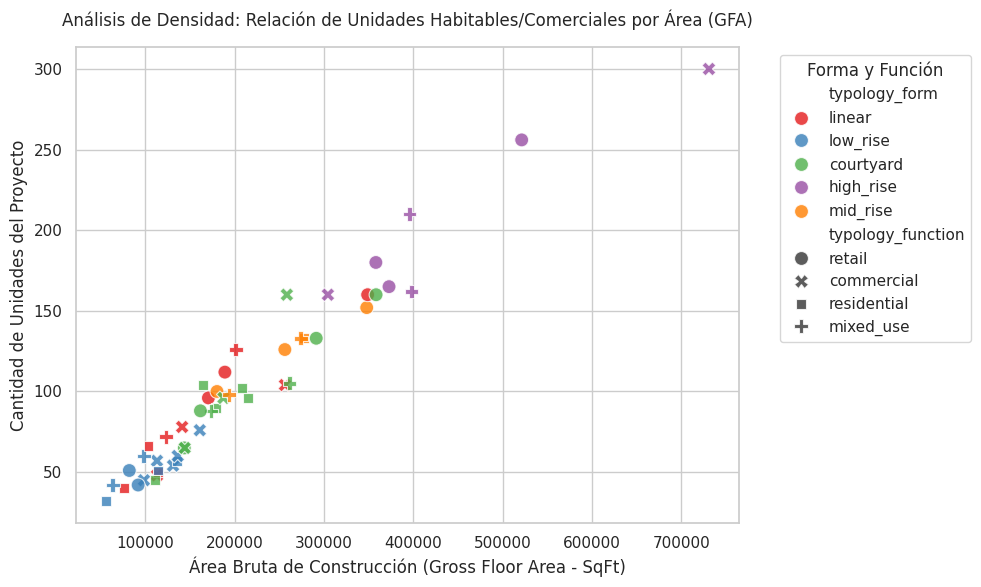

In [27]:
# Mantener consistencia estética
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'figure.titlesize': 14})

# Unir conjuntos de datos base
df_comp = df_performance[df_performance['project_status'] == 'completed'].copy()
df_full_projects = df_comp.merge(df_projects, on='project_id')

# 1. Calcular margen neto en USD y porcentaje de desviación de coste
df_full_projects['net_margin_usd'] = df_full_projects['planned_cost'] - df_full_projects['final_cost']
df_full_projects['cost_dev_pct'] = ((df_full_projects['final_cost'] - df_full_projects['planned_cost']) / df_full_projects['planned_cost']) * 100

# 2. Calcular horas de gestión (Project Manager + Direction) por proyecto
management_hours = df_hours[df_hours['role_in_project'].isin(['project_manager', 'direction'])].groupby('project_id')['hours_logged'].sum().reset_index()
management_hours.rename(columns={'hours_logged': 'management_hours'}, inplace=True)
df_efficiency = df_full_projects.merge(management_hours, on='project_id', how='left').fillna({'management_hours': 0})

# =====================================================================
# GRÁFICA 16: Densidad Inmobiliaria (Unidades vs Área Construída por Forma)
# =====================================================================
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_projects,
    x='gross_floor_area',
    y='units',
    hue='typology_form',
    style='typology_function',
    palette='Set1',
    s=100,
    alpha=0.8
)

plt.title('Análisis de Densidad: Relación de Unidades Habitables/Comerciales por Área (GFA)', pad=15)
plt.xlabel('Área Bruta de Construcción (Gross Floor Area - SqFt)')
plt.ylabel('Cantidad de Unidades del Proyecto')
plt.legend(title='Forma y Función', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


> **Interpretación de resultados:** Tras analizar la relación entre el Área Bruta de Construcción (GFA) y la cantidad de unidades habitables/comerciales, presentamos las conclusiones técnicas derivadas de la visualización:

* **Correlación lineal predominante**: Existe una relación directa y altamente predecible entre el tamaño del proyecto (GFA) y la cantidad de unidades resultantes. Esto demuestra que nuestra metodología de diseño es consistente y escalable, permitiendo realizar estimaciones fiables desde las etapas tempranas de planificación.
* **Especialización por tipología**: Los proyectos de tipo *high_rise* y *mid_rise* (representados por puntos morados y naranjas) se ubican en los cuadrantes de mayor área y densidad, consolidándose como nuestras tipologías de mayor capacidad volumétrica y eficiencia comercial.
* **Eficiencia atípica**: Se observa un caso de éxito excepcional donde un proyecto ha logrado maximizar la densidad (alcanzando 300 unidades) con un uso del área (GFA) proporcionalmente optimizado, alejándose ligeramente de la tendencia general hacia arriba. Este diseño debería ser estudiado como referencia para futuros proyectos de alta escala.
* **Conclusión estratégica**: La consistencia observada en la distribución nos brinda una ventaja competitiva en la viabilidad de proyectos. Para maximizar la rentabilidad futura, la estrategia debe enfocarse en replicar las lógicas de empaquetamiento volumétrico de los proyectos *high_rise*, los cuales han demostrado ser los más eficientes para densificar el uso del suelo sin comprometer los estándares de diseño.

### **4.17 — Impacto del Management: Esfuerzo de Gestión vs. Desviación Económica**

En este apartado, evaluamos la relación entre la carga de horas invertidas en la dirección y gestión de proyectos frente a la salud financiera final. El objetivo es determinar si un mayor esfuerzo en horas de gestión se traduce efectivamente en un control más riguroso del presupuesto.

* **Objetivo**: Validar el retorno de inversión del esfuerzo administrativo. ¿Existe un punto de saturación donde invertir más horas de gestión no mejora el control financiero, o por el contrario, los proyectos con mayor dedicación de *Project Management* son los que presentan desviaciones presupuestarias más cercanas a cero?
* **Metodología**: Utilizamos un gráfico de dispersión donde el eje X mide la dedicación horaria total (sumatoria de *Project Managers* y *Direction*), y el eje Y representa la desviación porcentual del costo. La línea roja marca el equilibrio presupuestario. Segmentar por `typology_form` y escalar por `planned_cost` nos permite identificar si este comportamiento es constante para todo tipo de obra o si varía significativamente según la escala y complejidad del edificio.

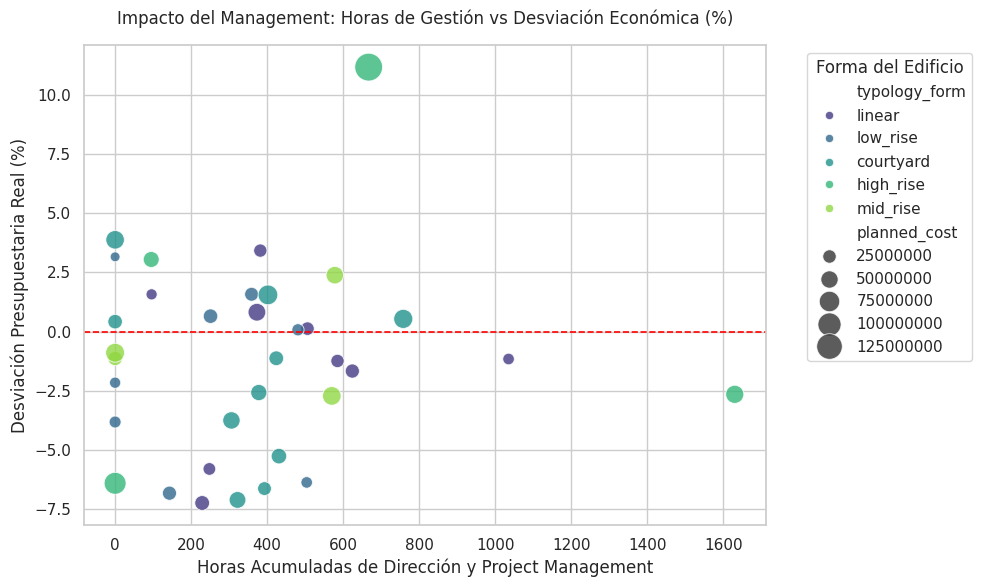

In [28]:
# =====================================================================
# GRÁFICA 17: Esfuerzo de Gestión vs Desviación Presupuestaria
# =====================================================================
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_efficiency,
    x='management_hours',
    y='cost_dev_pct',
    hue='typology_form',
    size='planned_cost',
    sizes=(50, 400),
    palette='viridis',
    alpha=0.8
)
plt.axhline(0, color='red', linestyle='--', linewidth=1.2)

plt.title('Impacto del Management: Horas de Gestión vs Desviación Económica (%)', pad=15)
plt.xlabel('Horas Acumuladas de Dirección y Project Management')
plt.ylabel('Desviación Presupuestaria Real (%)')
plt.legend(title='Forma del Edificio', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

> **Interpretación de resultados:** El gráfico evidencia que no existe una correlación lineal directa entre el incremento de las horas de gestión y la reducción de la desviación presupuestaria. Si bien la mayoría de los proyectos mantienen un control financiero robusto independientemente del esfuerzo administrativo, se identifica un punto de saturación donde una inversión excesiva en horas de *management* no garantiza una mejora en los márgenes. Asimismo, destaca un caso crítico de gran envergadura con una desviación positiva significativa, lo que sugiere que en proyectos de alta escala, la complejidad técnica puede neutralizar la efectividad de la gestión administrativa estándar, requiriendo un enfoque de mitigación basado específicamente en riesgos financieros en lugar de una carga horaria masiva.

### **4.18 — Eficiencia Operativa: Productividad del Dibujo Técnico**

Como complemento al análisis de cargas por sede, evaluamos aquí la productividad específica del equipo de delineantes (*drafters*). El objetivo es normalizar la producción de planos y modelos respecto a la magnitud de los proyectos, determinando la eficiencia espacial por hora trabajada.

* **Objetivo**: Identificar qué tipologías arquitectónicas son más "densas" en términos de trabajo técnico. ¿Requieren ciertas formas mayor inversión de horas por metro cuadrado debido a su complejidad geométrica, o nuestra estandarización permite una productividad constante?
* **Metodología**: Calculamos la métrica de *SqFt por hora de delineante* (`gross_floor_area` / `hours_logged`). Utilizamos un gráfico de cajas (*boxplot*) para visualizar la dispersión y los valores atípicos en la productividad por tipología (`typology_form`), lo que nos permite detectar ineficiencias o procesos de diseño excepcionalmente optimizados.

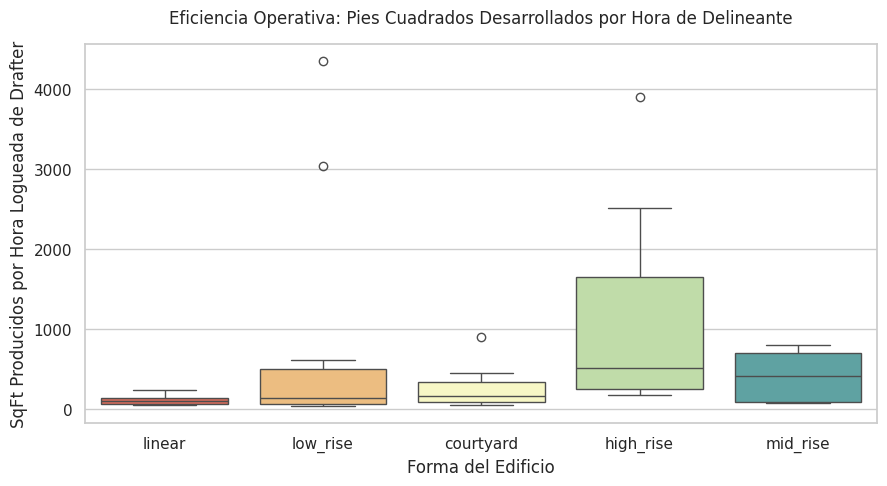

In [29]:
# =====================================================================
# GRÁFICA 18: Productividad del Dibujo Técnico (Horas Drafter por Área)
# =====================================================================
# Calcular el total de horas de dibujo (Drafter) por proyecto
drafter_hours = df_hours[df_hours['role_in_project'] == 'drafter'].groupby('project_id')['hours_logged'].sum().reset_index()
df_drafter_eff = df_projects.merge(drafter_hours, on='project_id')

# Calcular métrica derivada: Pies cuadrados dibujados por hora de delineante
df_drafter_eff['sqft_per_drafter_hour'] = df_drafter_eff['gross_floor_area'] / df_drafter_eff['hours_logged']

plt.figure(figsize=(9, 5))
sns.boxplot(
    data=df_drafter_eff,
    x='typology_form',
    y='sqft_per_drafter_hour',
    palette='Spectral',
    hue='typology_form',
    legend=False
)

plt.title('Eficiencia Operativa: Pies Cuadrados Desarrollados por Hora de Delineante', pad=15)
plt.xlabel('Forma del Edificio')
plt.ylabel('SqFt Producidos por Hora Logueada de Drafter')
plt.tight_layout()
plt.show()

> **Interpretación de resultados:** El gráfico evidencia una variabilidad significativa en la eficiencia operativa según la forma del edificio. Las tipologías *high_rise* destacan como las más eficientes en términos de productividad de delineación, alcanzando los mayores promedios de pies cuadrados por hora trabajada, lo que sugiere procesos de diseño más estandarizados o repetitivos. Por el contrario, las tipologías *linear* muestran una productividad constante pero notablemente baja, lo que puede indicar una mayor complejidad técnica o necesidad de detalle por unidad de superficie. La presencia de valores atípicos (*outliers*) en *low_rise* y *high_rise* señala la existencia de proyectos excepcionalmente optimizados, los cuales deberían ser analizados en profundidad para identificar buenas prácticas que puedan escalarse al resto de la firma.

### **4.19 — Pipeline de Operaciones: Capital en Ejecución**

Para cerrar nuestra visión estratégica, evaluamos el estado actual de nuestra cartera de proyectos en construcción (*in_progress*). El objetivo es visualizar la concentración de capital comprometido según el uso y la complejidad formal de los edificios, permitiéndonos entender dónde reside la mayor exposición financiera de la empresa en este momento.

* **Objetivo**: Identificar la composición de nuestra cartera activa. ¿Estamos sobreexpuestos en algún segmento de uso específico? Esta métrica es fundamental para la gestión de riesgos financieros y la planificación de los próximos ciclos de contratación.
* **Metodología**: Utilizamos un gráfico de barras apiladas o agrupadas que suma la inversión planificada (`planned_cost`), segmentando por el uso del edificio (`typology_function`) y la forma (`typology_form`). Esto nos ofrece una instantánea clara del volumen de negocio activo y la diversidad de nuestra huella constructiva actual.

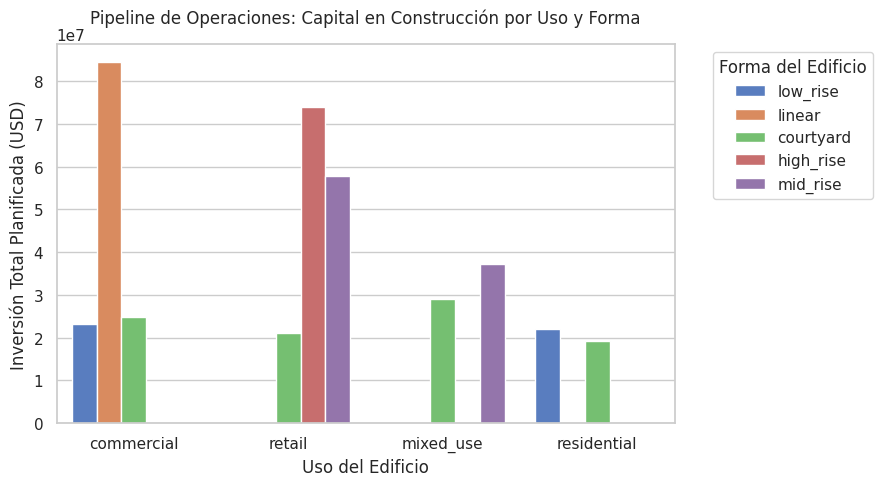

In [30]:
# Mantener consistencia estética limpia y ejecutiva
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'figure.titlesize': 14})

# Unir datos base para análisis cruzados
df_active = df_performance[df_performance['project_status'] == 'in_progress'].copy()
df_active_full = df_active.merge(df_projects, on='project_id')

# =====================================================================
# GRÁFICA 19: Pipeline de Proyectos Activos (Coste Estimado por Tipología)
# =====================================================================
plt.figure(figsize=(9, 5))
# Ver cuánto dinero (cartera estimada) hay comprometido en los proyectos en construcción
sns.barplot(
    data=df_active_full,
    x='typology_function',
    y='planned_cost',
    hue='typology_form',
    estimator=sum,
    errorbar=None,
    palette='muted'
)

plt.title('Pipeline de Operaciones: Capital en Construcción por Uso y Forma', pad=15)
plt.xlabel('Uso del Edificio')
plt.ylabel('Inversión Total Planificada (USD)')
plt.legend(title='Forma del Edificio', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

> **Interpretación de resultados:** El gráfico evidencia una concentración estratégica del capital en proyectos de alto impacto comercial y minorista (*retail*), los cuales lideran la inversión total planificada. Se observa que la tipología *linear* domina el segmento comercial, mientras que los desarrollos *high_rise* y *mid_rise* concentran la mayor parte de la inversión en proyectos de *retail*. Esta distribución sugiere una especialización donde los proyectos de mayor escala y presupuesto están intrínsecamente ligados a usos comerciales, mientras que el sector residencial se mantiene con una participación más contenida. La ausencia de proyectos *high_rise* en el sector residencial indica una oportunidad de crecimiento para capturar proyectos de mayor valor en este segmento, equilibrando así la exposición financiera de la firma frente a la volatilidad del mercado comercial y *retail*.

### **4.20 — Estructura de Capital Humano: Distribución de Seniority por Sede**

Para finalizar el informe, realizamos una evaluación del perfil de experiencia de nuestro personal (*seniority*). Este análisis nos permite entender la composición de la fuerza laboral y anticipar necesidades de mentoría, capacitación o reclutamiento estratégico.

* **Objetivo**: Detectar brechas generacionales o desequilibrios en el nivel de experiencia. ¿Contamos con una base sólida de personal *junior* para asegurar el relevo, o dependemos mayoritariamente de perfiles *senior* en una sede específica?
* **Metodología**: Utilizamos un gráfico de densidad (*KDE plot*) para visualizar la distribución de años de experiencia (`experience_years`) segmentada por oficina (`office_location`). Esta herramienta es ideal para identificar la "moda" o el nivel de experiencia predominante en cada sede, permitiéndonos visualizar si los perfiles se concentran en etapas tempranas, intermedias o avanzadas de su carrera profesional.

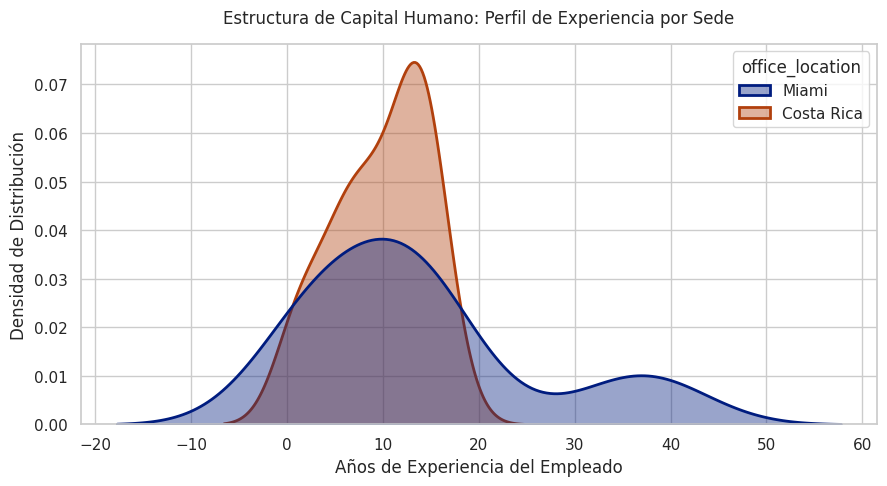

In [31]:
# =====================================================================
# GRÁFICA 20: Pirámide de Experiencia (Seniority del Staff por Sede)
# =====================================================================
plt.figure(figsize=(9, 5))
# Analizar la distribución de los años de experiencia para evaluar el relevo generacional
sns.kdeplot(
    data=df_employees,
    x='experience_years',
    hue='office_location',
    fill=True,
    common_norm=False,
    palette='dark',
    alpha=0.4,
    linewidth=2
)

plt.title('Estructura de Capital Humano: Perfil de Experiencia por Sede', pad=15)
plt.xlabel('Años de Experiencia del Empleado')
plt.ylabel('Densidad de Distribución')
plt.tight_layout()
plt.show()

> **Interpretación de resultados:** El gráfico evidencia una disparidad marcada en la madurez profesional de ambas sedes. La oficina de Costa Rica presenta una distribución altamente concentrada en el rango de los 10 a 15 años de experiencia, lo que sugiere un equipo de perfil técnico muy consolidado y especializado. Por el contrario, la sede de Miami muestra una distribución mucho más dispersa con una "cola" prolongada hacia la derecha, lo que indica una mayor heterogeneidad que incluye tanto perfiles junior como una presencia significativa de personal senior (30+ años de experiencia), probablemente vinculada a roles de dirección y estrategia. Esta estructura es complementaria: mientras Costa Rica garantiza una ejecución técnica estable y experta, Miami aporta la diversidad de criterio y el liderazgo necesario para la gestión de proyectos de alto nivel.

### **4.21 — Análisis de Complejidad: Diseño Arquitectónico y Escala Vertical**

Para concluir este proceso de evaluación, examinamos la eficiencia del esfuerzo de diseño arquitectónico en relación con la escala vertical de los proyectos. El objetivo es determinar si la carga de horas de arquitectura crece de forma proporcional al número de pisos o si existen economías de escala.

* **Objetivo**: Evaluar la "densidad de diseño". ¿La adición de un nivel extra al edificio aumenta el esfuerzo de arquitectura de manera lineal, o se logran eficiencias en proyectos de mayor altura debido a la repetición de plantas?
* **Metodología**: Utilizamos un gráfico de regresión (`regplot`) que cruza la cantidad de pisos (`floors`) con las horas totales de arquitectura (`hours_logged`). La línea de tendencia nos permitirá cuantificar el costo horario marginal por cada piso adicional, ayudándonos a ajustar las estimaciones presupuestarias en futuras propuestas de edificios de altura.

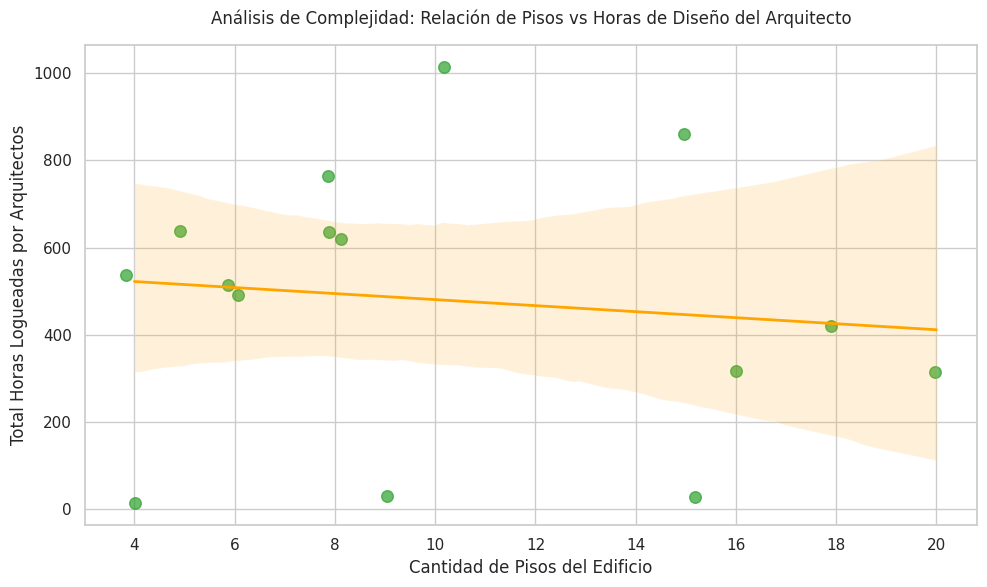

In [32]:
# =====================================================================
# GRÁFICA 21: Esfuerzo de Diseño vs Escala (Horas de Arquitecto por Piso)
# =====================================================================
# Filtrar horas logueadas exclusivamente por el rol de arquitecto
arch_hours = df_hours[df_hours['role_in_project'] == 'architect'].groupby('project_id')['hours_logged'].sum().reset_index()
df_arch_scale = df_projects.merge(arch_hours, on='project_id')

plt.figure(figsize=(10, 6))
sns.regplot(
    data=df_arch_scale,
    x='floors',
    y='hours_logged',
    scatter_kws={'alpha':0.7, 'color':'#2ca02c', 's':70},
    line_kws={'color':'orange', 'linewidth':2},
    x_jitter=0.2
)

plt.title('Análisis de Complejidad: Relación de Pisos vs Horas de Diseño del Arquitecto', pad=15)
plt.xlabel('Cantidad de Pisos del Edificio')
plt.ylabel('Total Horas Logueadas por Arquitectos')
plt.tight_layout()
plt.show()

> **Interpretación de resultados:** El gráfico evidencia una tendencia contraintuitiva en la relación entre la escala vertical y el esfuerzo de diseño. Contrario a lo que podría esperarse, no existe un aumento lineal de las horas de arquitectura conforme aumenta la cantidad de pisos. De hecho, la línea de tendencia muestra una ligera pendiente negativa, lo que sugiere una **economía de escala operativa**: a medida que los edificios son más altos (más pisos), los arquitectos dedican proporcionalmente menos horas totales, probablemente debido a la estandarización y repetición de las plantas tipo en proyectos de mayor altura. La amplia zona de sombra (intervalo de confianza) indica una alta variabilidad en los proyectos de menor escala, donde factores específicos del diseño o imprevistos tienen un mayor peso relativo en el esfuerzo de arquitectura.

### **4.22 — Análisis de Densidad Interna: Materialidad y Capacidad Volumétrica**

Este indicador analiza la correlación entre la tecnología constructiva adoptada (material estructural) y la capacidad de densificación habitacional o comercial de nuestros proyectos. El objetivo es entender si ciertos materiales habilitan una mayor fragmentación de unidades o si, por el contrario, dictan escalas de proyecto más monolíticas.

* **Objetivo**: Determinar la eficiencia de empaquetamiento volumétrico según el material. ¿Los proyectos en acero permiten una mayor densidad de unidades en comparación con el hormigón o estructuras mixtas, o es el material una variable neutral frente a la densidad final?
* **Metodología**: Utilizamos un diagrama de caja (*boxplot*) para analizar la distribución del número de unidades (`units`) por material estructural (`structural_material`). Este análisis es crucial para la estimación de viabilidad en fases tempranas, ya que nos permitirá predecir el potencial de unidades según la decisión estructural preliminar.

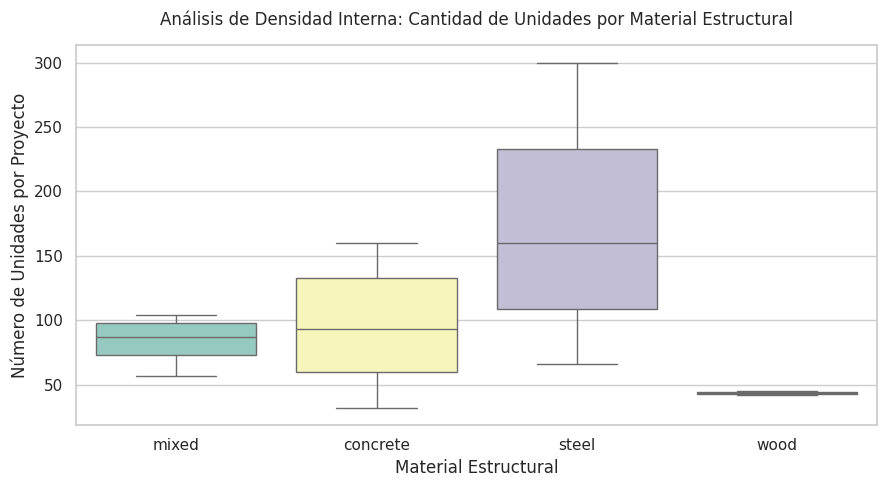

In [33]:
# 1. Configuración de estilo básico para la gráfica 22
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'figure.titlesize': 14})

# Unir conjuntos de datos base
df_comp = df_performance[df_performance['project_status'] == 'completed'].copy()
df_full_projects = df_comp.merge(df_projects, on='project_id')
df_geo_mix = df_full_projects.merge(df_clients, on='client_id')

# =====================================================================
# GRÁFICA 22: Distribución de Unidades Habitables según el Material
# =====================================================================
plt.figure(figsize=(9, 5))
# Analizar la escala residencial/comercial interna según la tecnología constructiva
sns.boxplot(
    data=df_geo_mix,
    x='structural_material',
    y='units',
    palette='Set3',
    hue='structural_material',
    legend=False
)

plt.title('Análisis de Densidad Interna: Cantidad de Unidades por Material Estructural', pad=15)
plt.xlabel('Material Estructural')
plt.ylabel('Número de Unidades por Proyecto')
plt.tight_layout()
plt.show()

> **Interpretación de resultados:** El gráfico evidencia una correlación clara entre la elección del material estructural y la capacidad de densificación del proyecto. El acero (*steel*) destaca como el material que permite la mayor variabilidad y densidad de unidades, albergando los proyectos con mayor cantidad de unidades habitacionales/comerciales, lo que valida su uso para desarrollos de gran escala. Por otro lado, las estructuras de hormigón (*concrete*) y sistemas mixtos (*mixed*) muestran una densidad media y más contenida, mientras que la madera (*wood*) presenta una escala de proyecto muy limitada y constante, sugiriendo su uso exclusivo en tipologías de baja densidad. Esta información es crítica para la etapa de factibilidad, pues permite alinear las expectativas comerciales del cliente con las capacidades intrínsecas de cada sistema constructivo desde la fase de diseño preliminar.

### **4.23 — Análisis de Huella Geográfica: Distribución de Proyectos**

Más allá de los datos financieros y operativos, la ubicación geográfica de nuestra cartera define nuestra logística y capacidad de respuesta. Este mapa interactivo nos permite visualizar la densidad de operaciones en nuestras regiones clave y cómo se distribuyen nuestras tipologías de construcción en el territorio.

* **Objetivo**: Identificar polos de concentración de proyectos. Esta herramienta es vital para la logística de visitas a obra, la gestión de equipos locales y la identificación de mercados donde nuestra presencia es aún emergente o requiere consolidación.
* **Metodología**: Implementamos una visualización interactiva utilizando la librería *Folium*. Cada proyecto se representa mediante un marcador geolocalizado con un sistema de *Marker Clusters* (agrupación de marcadores), lo cual permite manejar una gran cantidad de puntos sin saturar visualmente el mapa. Los pines están codificados por colores para diferenciar tipologías (*high_rise* vs. otros), permitiendo un acceso rápido a la información detallada de cada proyecto mediante *popups* interactivos.

In [34]:
import folium
from folium.plugins import MarkerCluster

# =====================================================================
# GRÁFICA 23: MAPA INTERACTIVO DE CLUSTERS DE PROYECTOS (FOLIUM)
# =====================================================================
# Definimos coordenadas base aproximadas para simular la dispersión en las 3 sedes/regiones
centroides = {
    'USA': [25.7617, -80.1918],       # Centro en Miami/Florida
    'Costa Rica': [9.9281, -84.0907],  # Centro en San José
    'Panama': [8.9824, -79.5199]       # Centro en Ciudad de Panamá
}

# Crear diccionarios para dispersar los puntos aleatoriamente alrededor del centroide de cada país
np.random.seed(42) # Consistencia de coordenadas
latitudes = []
longitudes = []

for country in df_geo_mix['client_country']:
    base_coord = centroides.get(country, [9.9281, -84.0907])
    # Añadir pequeña dispersión (jitter) para que no queden todos los pines en el mismo pixel
    latitudes.append(base_coord[0] + np.random.uniform(-0.15, 0.15))
    longitudes.append(base_coord[1] + np.random.uniform(-0.15, 0.15))

df_geo_mix['lat'] = latitudes
df_geo_mix['lon'] = longitudes

# Inicializar el mapa de Folium centrado en una posición intermedia del mapa macro
mapa_proyectos = folium.Map(location=[15.0, -82.0], zoom_start=4, tiles='OpenStreetMap')

# Crear el plugin de agrupación de marcadores (Marker Cluster)
marker_cluster = MarkerCluster().add_to(mapa_proyectos)

# Iterar sobre los proyectos para pintar los pines interactivos
for idx, row in df_geo_mix.iterrows():
    # Definir color del pin según el estado o tipo
    color_pin = 'blue' if row['typology_form'] == 'high_rise' else 'green'

    # Crear el texto emergente (Popup) con diseño HTML limpio
    html_popup = f"""
    <div style='font-family: Arial, sans-serif; width: 200px;'>
        <h4 style='margin:0 0 5px 0; color:#1f77b4;'>{row['project_name']}</h4>
        <b>Uso:</b> {row['typology_function']}<br>
        <b>Forma:</b> {row['typology_form']}<br>
        <b>Pisos:</b> {row['floors']}<br>
        <b>Cliente:</b> {row['client_name']}
    </div>
    """

    folium.Marker(
        location=[row['lat'], row['lon']],
        popup=folium.Popup(html_popup, max_width=250),
        icon=folium.Icon(color=color_pin, icon='building', library='fa')
    ).add_to(marker_cluster)

# Mostrar el mapa interactivo en la celda de Colab
mapa_proyectos